In [1]:
# ══════════════════════════════════════════════════════════════════
# CELL 1 — DATA INGESTION (CIC-DDoS2019 — Full Parquet Dataset)
# ══════════════════════════════════════════════════════════════════
import os, time, glob, warnings, shutil
import pandas as pd
warnings.filterwarnings('ignore')

t0 = time.time()

# ─────────────────────────────────────────────────────────
# 1 ▸ MOUNT GOOGLE DRIVE
# ─────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE = '/content/drive/MyDrive/Colab Notebooks'
DDOS_DIR = os.path.join(DRIVE, 'CIC-DDoS2019')
os.makedirs(DRIVE, exist_ok=True)

print('='*70)
print('  CELL 1 — DATA INGESTION (CIC-DDoS2019 — Full Dataset)')
print('='*70)

# ─────────────────────────────────────────────────────────
# 2 ▸ DOWNLOAD IF NOT IN DRIVE
# ─────────────────────────────────────────────────────────
# Check if parquet files already exist
existing_pq = glob.glob(os.path.join(DDOS_DIR, '*.parquet'))

if len(existing_pq) >= 5:
    print(f'\n  ✅ Dataset found in Drive: {DDOS_DIR}')
    print(f'     Parquet files: {len(existing_pq)}')
else:
    print(f'\n  Dataset not found (or incomplete). Downloading from Kaggle ...')
    os.makedirs(DDOS_DIR, exist_ok=True)
    downloaded = False

    # ── Method 1: kagglehub ──
    try:
        import kagglehub
        path = kagglehub.dataset_download('dhoogla/cicddos2019')
        print(f'  kagglehub downloaded to: {path}')
        # Copy all parquet files to Drive
        pq_files = []
        for root, dirs, files in os.walk(path):
            for f in files:
                if f.endswith('.parquet'):
                    src = os.path.join(root, f)
                    dst = os.path.join(DDOS_DIR, f)
                    shutil.copy2(src, dst)
                    pq_files.append(f)
        if pq_files:
            print(f'  Copied {len(pq_files)} parquet files to Drive.')
            downloaded = True
    except Exception as e:
        print(f'  kagglehub failed: {e}')

    # ── Method 2: opendatasets ──
    if not downloaded:
        try:
            import subprocess
            subprocess.run(['pip', 'install', '-q', 'opendatasets'], check=True)
            import opendatasets as od
            od.download('https://www.kaggle.com/datasets/dhoogla/cicddos2019',
                        data_dir='/content/')
            for root, dirs, files in os.walk('/content/cicddos2019'):
                for f in files:
                    if f.endswith('.parquet'):
                        src = os.path.join(root, f)
                        dst = os.path.join(DDOS_DIR, f)
                        shutil.copy2(src, dst)
            downloaded = True
            print(f'  opendatasets: files copied to Drive.')
        except Exception as e:
            print(f'  opendatasets failed: {e}')

    # ── Method 3: manual upload ──
    if not downloaded:
        print('\n  ⚠ Automatic download failed.')
        print('  Please download from: https://www.kaggle.com/datasets/dhoogla/cicddos2019')
        print(f'  Upload all .parquet files to: {DDOS_DIR}')
        from google.colab import files
        uploaded = files.upload()
        for fname in uploaded:
            if fname.endswith('.parquet'):
                shutil.move(fname, os.path.join(DDOS_DIR, fname))
        downloaded = True

    existing_pq = glob.glob(os.path.join(DDOS_DIR, '*.parquet'))
    print(f'\n  ✅ {len(existing_pq)} parquet files saved to Drive.')

# ─────────────────────────────────────────────────────────
# 3 ▸ LIST & CATEGORISE FILES
# ─────────────────────────────────────────────────────────
existing_pq = sorted(glob.glob(os.path.join(DDOS_DIR, '*.parquet')))
train_files = [f for f in existing_pq if 'training' in os.path.basename(f).lower()]
test_files  = [f for f in existing_pq if 'testing' in os.path.basename(f).lower()]

print(f'\n{"─"*70}')
print(f'  PARQUET FILES INVENTORY')
print(f'{"─"*70}')
print(f'  Total files: {len(existing_pq)}')
print(f'  Training files: {len(train_files)}')
print(f'  Testing files : {len(test_files)}')
print(f'\n  {"File":<45} {"Size (MB)":>10}')
print(f'  {"─"*45} {"─"*10}')
total_size = 0
for f in existing_pq:
    sz = os.path.getsize(f) / 1024**2
    total_size += sz
    tag = '[TRAIN]' if 'training' in os.path.basename(f).lower() else '[TEST]'
    print(f'  {tag} {os.path.basename(f):<38} {sz:>8.2f} MB')
print(f'  {"TOTAL":<45} {total_size:>8.1f} MB')

# ─────────────────────────────────────────────────────────
# 4 ▸ LOAD & CONCATENATE ALL FILES
# ─────────────────────────────────────────────────────────
print(f'\n  Loading all parquet files ...')

dfs_train = []
dfs_test  = []

for f in train_files:
    tmp = pd.read_parquet(f)
    attack_name = os.path.basename(f).replace('-training.parquet', '')
    tmp['split'] = 'train'
    tmp['source_file'] = attack_name
    dfs_train.append(tmp)
    print(f'    TRAIN | {attack_name:<20} : {len(tmp):>8,} rows × {tmp.shape[1]} cols')

for f in test_files:
    tmp = pd.read_parquet(f)
    attack_name = os.path.basename(f).replace('-testing.parquet', '')
    tmp['split'] = 'test'
    tmp['source_file'] = attack_name
    dfs_test.append(tmp)
    print(f'    TEST  | {attack_name:<20} : {len(tmp):>8,} rows × {tmp.shape[1]} cols')

df_train = pd.concat(dfs_train, ignore_index=True) if dfs_train else pd.DataFrame()
df_test  = pd.concat(dfs_test, ignore_index=True) if dfs_test else pd.DataFrame()
df_all   = pd.concat([df_train, df_test], ignore_index=True)

print(f'\n  Combined train : {len(df_train):>10,} rows')
print(f'  Combined test  : {len(df_test):>10,} rows')
print(f'  Combined total : {len(df_all):>10,} rows × {df_all.shape[1]} columns')

# ─────────────────────────────────────────────────────────
# 5 ▸ INITIAL INSPECTION
# ─────────────────────────────────────────────────────────
print(f'\n{"─"*70}')
print(f'  INITIAL INSPECTION')
print(f'{"─"*70}')
print(f'  Memory usage: {df_all.memory_usage(deep=True).sum()/1024**2:.1f} MB')

# Columns
print(f'\n  Columns ({df_all.shape[1]}):')
for i, col in enumerate(df_all.columns):
    print(f'    {i+1:>3}. {col:<35} {str(df_all[col].dtype):<12}')

# Target column
target_col = None
for candidate in ['Label', 'label', ' Label']:
    if candidate in df_all.columns:
        target_col = candidate
        break

if target_col:
    print(f'\n  Target column: "{target_col}"')
    vc = df_all[target_col].value_counts().sort_values(ascending=False)
    print(f'  Class distribution (all data):')
    for cls, cnt in vc.items():
        pct = cnt / len(df_all) * 100
        print(f'    {str(cls):<25} : {cnt:>10,}  ({pct:.2f}%)')
    print(f'  Unique classes: {df_all[target_col].nunique()}')

    # Train/Test class breakdown
    if len(df_train) > 0:
        print(f'\n  Train-set class distribution:')
        vc_tr = df_train[target_col].value_counts()
        for cls, cnt in vc_tr.items():
            print(f'    {str(cls):<25} : {cnt:>10,}  ({cnt/len(df_train)*100:.2f}%)')

    if len(df_test) > 0:
        print(f'\n  Test-set class distribution:')
        vc_ts = df_test[target_col].value_counts()
        for cls, cnt in vc_ts.items():
            print(f'    {str(cls):<25} : {cnt:>10,}  ({cnt/len(df_test)*100:.2f}%)')
else:
    print('\n  ⚠ Target column not found — check column names above.')

# Missing / Inf / Duplicates
total_miss = df_all.isnull().sum().sum()
num_cols = df_all.select_dtypes(include='number').columns
inf_count = df_all[num_cols].isin([float('inf'), float('-inf')]).sum().sum()
n_dup = df_all.duplicated().sum()

print(f'\n  Missing values : {total_miss:,}')
print(f'  Infinite values: {inf_count:,}')
print(f'  Duplicate rows : {n_dup:,}')

# ─────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────
elapsed = time.time() - t0
print(f'\n{"="*70}')
print(f'  INGESTION SUMMARY')
print(f'{"="*70}')
print(f'  Dataset        : CIC-DDoS2019 (Full — dhoogla/Kaggle)')
print(f'  Reference       : Sharafaldin et al., IEEE ICCST 2019')
print(f'  Format          : Parquet (cleaned, V2)')
print(f'  Files           : {len(existing_pq)} ({len(train_files)} train + {len(test_files)} test)')
print(f'  Total size      : {total_size:.1f} MB')
print(f'  Total rows      : {len(df_all):,}')
print(f'  Columns         : {df_all.shape[1]}')
print(f'  Target          : {target_col if target_col else "NOT FOUND"}')
print(f'  Attack classes  : {df_all[target_col].nunique() if target_col else "N/A"}')
print(f'  Missing values  : {total_miss:,}')
print(f'  Inf values      : {inf_count:,}')
print(f'  Duplicates      : {n_dup:,}')
print(f'  Load time       : {elapsed:.1f}s')
print(f'{"="*70}')
print(f'  ✅ Ready for Cell 2 — Textual EDA')
print(f'{"="*70}')


Mounted at /content/drive
  CELL 1 — DATA INGESTION (CIC-DDoS2019 — Full Dataset)

  ✅ Dataset found in Drive: /content/drive/MyDrive/Colab Notebooks/CIC-DDoS2019
     Parquet files: 17

──────────────────────────────────────────────────────────────────────
  PARQUET FILES INVENTORY
──────────────────────────────────────────────────────────────────────
  Total files: 17
  Training files: 7
  Testing files : 10

  File                                           Size (MB)
  ───────────────────────────────────────────── ──────────
  [TEST] DNS-testing.parquet                        0.49 MB
  [TEST] LDAP-testing.parquet                       0.21 MB
  [TRAIN] LDAP-training.parquet                      0.59 MB
  [TEST] MSSQL-testing.parquet                      0.40 MB
  [TRAIN] MSSQL-training.parquet                     0.55 MB
  [TEST] NTP-testing.parquet                        9.05 MB
  [TEST] NetBIOS-testing.parquet                    0.24 MB
  [TRAIN] NetBIOS-training.parquet           

In [2]:
# ══════════════════════════════════════════════════════════════════
# CELL 2 — TEXTUAL EDA (CIC-DDoS2019)
# ══════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')

print('='*70)
print('  CELL 2 — TEXTUAL EDA (CIC-DDoS2019)')
print('='*70)

# ─────────────────────────────────────────────────────────
# Separate metadata from features
# ─────────────────────────────────────────────────────────
meta_cols = ['Label', 'split', 'source_file']
feat_cols = [c for c in df_all.columns if c not in meta_cols]

print(f'\n  Total columns    : {df_all.shape[1]}')
print(f'  Metadata columns : {len(meta_cols)} → {meta_cols}')
print(f'  Feature columns  : {len(feat_cols)}')

# ─────────────────────────────────────────────────────────
# 1 ▸ DATASET DIMENSIONS
# ─────────────────────────────────────────────────────────
print(f'\n{"─"*70}')
print(f'  [1] DATASET DIMENSIONS')
print(f'{"─"*70}')
print(f'  Total samples  : {len(df_all):,}')
print(f'  Train samples  : {len(df_train):,} ({len(df_train)/len(df_all)*100:.1f}%)')
print(f'  Test samples   : {len(df_test):,} ({len(df_test)/len(df_all)*100:.1f}%)')
print(f'  Features       : {len(feat_cols)}')
print(f'  Memory         : {df_all.memory_usage(deep=True).sum()/1024**2:.1f} MB')

# ─────────────────────────────────────────────────────────
# 2 ▸ DATA TYPES
# ─────────────────────────────────────────────────────────
print(f'\n{"─"*70}')
print(f'  [2] DATA TYPES (feature columns only)')
print(f'{"─"*70}')
dtype_counts = df_all[feat_cols].dtypes.value_counts()
for dt, cnt in dtype_counts.items():
    cols_of_type = df_all[feat_cols].select_dtypes(include=[dt]).columns.tolist()
    print(f'  {str(dt):<12} : {cnt:>3} columns')

# ─────────────────────────────────────────────────────────
# 3 ▸ TARGET ANALYSIS (multi-class)
# ─────────────────────────────────────────────────────────
print(f'\n{"─"*70}')
print(f'  [3] TARGET ANALYSIS — MULTI-CLASS')
print(f'{"─"*70}')

vc = df_all['Label'].value_counts().sort_values(ascending=False)
print(f'\n  {"Class":<25} {"Count":>10} {"Pct":>8} {"Cum%":>8}')
print(f'  {"─"*25} {"─"*10} {"─"*8} {"─"*8}')
cum = 0
for cls, cnt in vc.items():
    pct = cnt / len(df_all) * 100
    cum += pct
    print(f'  {str(cls):<25} {cnt:>10,} {pct:>7.2f}% {cum:>7.1f}%')

# Binary view
n_benign = (df_all['Label'] == 'Benign').sum()
n_attack = len(df_all) - n_benign
print(f'\n  Binary view:')
print(f'    Benign : {n_benign:>10,} ({n_benign/len(df_all)*100:.2f}%)')
print(f'    Attack : {n_attack:>10,} ({n_attack/len(df_all)*100:.2f}%)')
print(f'    Ratio  : {min(n_benign,n_attack)/max(n_benign,n_attack):.3f}')

# Imbalance ratio (smallest vs largest class)
print(f'\n  Multi-class imbalance:')
print(f'    Largest class  : {vc.index[0]} ({vc.iloc[0]:,})')
print(f'    Smallest class : {vc.index[-1]} ({vc.iloc[-1]:,})')
print(f'    Ratio (min/max): {vc.iloc[-1]/vc.iloc[0]:.5f} (1:{vc.iloc[0]//max(vc.iloc[-1],1)})')

# ─────────────────────────────────────────────────────────
# 4 ▸ ATTACK TAXONOMY
# ─────────────────────────────────────────────────────────
print(f'\n{"─"*70}')
print(f'  [4] ATTACK TAXONOMY')
print(f'{"─"*70}')

# Group by attack family
attack_families = {
    'Reflection-based (DrDoS)': ['DrDoS_NTP', 'DrDoS_DNS', 'DrDoS_LDAP',
                                  'DrDoS_MSSQL', 'DrDoS_NetBIOS', 'DrDoS_SNMP',
                                  'DrDoS_UDP'],
    'Exploitation-based (Flood)': ['Syn', 'UDP', 'UDP-lag', 'UDPLag'],
    'Application-layer': ['WebDDoS'],
    'Amplification': ['TFTP', 'MSSQL', 'LDAP', 'NetBIOS', 'Portmap'],
    'Benign': ['Benign']
}

for family, members in attack_families.items():
    present = [m for m in members if m in vc.index]
    total = sum(vc.get(m, 0) for m in present)
    print(f'\n  {family}:')
    for m in present:
        print(f'    {m:<25} : {vc[m]:>10,}')
    print(f'    {"SUBTOTAL":<25} : {total:>10,} ({total/len(df_all)*100:.2f}%)')

# ─────────────────────────────────────────────────────────
# 5 ▸ TRAIN vs TEST CLASS OVERLAP
# ─────────────────────────────────────────────────────────
print(f'\n{"─"*70}')
print(f'  [5] TRAIN vs TEST — CLASS OVERLAP')
print(f'{"─"*70}')

train_classes = set(df_train['Label'].unique())
test_classes  = set(df_test['Label'].unique())
common = train_classes & test_classes
only_train = train_classes - test_classes
only_test  = test_classes - train_classes

print(f'  Train classes : {len(train_classes)}')
print(f'  Test classes  : {len(test_classes)}')
print(f'  Common        : {len(common)} → {sorted(common)}')
if only_train:
    print(f'  Only in train : {len(only_train)} → {sorted(only_train)}')
if only_test:
    print(f'  Only in test  : {len(only_test)} → {sorted(only_test)}')
    print(f'  ⚠ {len(only_test)} unseen attack types in test set (zero-day scenario)')

# ─────────────────────────────────────────────────────────
# 6 ▸ FEATURE STATISTICS
# ─────────────────────────────────────────────────────────
print(f'\n{"─"*70}')
print(f'  [6] FEATURE STATISTICS')
print(f'{"─"*70}')

desc = df_all[feat_cols].describe().T
print(f'\n  Numeric features summary:')
print(f'  {"Feature":<30} {"Min":>12} {"Max":>14} {"Mean":>14} {"Std":>14} {"Zeros%":>8}')
print(f'  {"─"*30} {"─"*12} {"─"*14} {"─"*14} {"─"*14} {"─"*8}')

zero_pcts = {}
for col in feat_cols:
    if df_all[col].dtype in ['int8', 'int16', 'int32', 'int64', 'float32', 'float64']:
        zero_pct = (df_all[col] == 0).sum() / len(df_all) * 100
        zero_pcts[col] = zero_pct
        print(f'  {col:<30} {desc.loc[col,"min"]:>12.2f} '
              f'{desc.loc[col,"max"]:>14.2f} {desc.loc[col,"mean"]:>14.4f} '
              f'{desc.loc[col,"std"]:>14.4f} {zero_pct:>7.1f}%')

# ─────────────────────────────────────────────────────────
# 7 ▸ CONSTANT / NEAR-CONSTANT FEATURES
# ─────────────────────────────────────────────────────────
print(f'\n{"─"*70}')
print(f'  [7] CONSTANT / NEAR-CONSTANT FEATURES')
print(f'{"─"*70}')

const_feats = []
near_const  = []
for col in feat_cols:
    nuniq = df_all[col].nunique()
    if nuniq <= 1:
        const_feats.append(col)
    elif zero_pcts.get(col, 0) > 99.0:
        near_const.append((col, zero_pcts[col]))

print(f'  Constant features (1 unique value): {len(const_feats)}')
for c in const_feats:
    print(f'    → {c} (value = {df_all[c].iloc[0]})')

print(f'  Near-constant features (>99% zeros): {len(near_const)}')
for c, pct in near_const:
    print(f'    → {c} ({pct:.1f}% zeros)')

# ─────────────────────────────────────────────────────────
# 8 ▸ PROTOCOL DISTRIBUTION
# ─────────────────────────────────────────────────────────
print(f'\n{"─"*70}')
print(f'  [8] PROTOCOL DISTRIBUTION')
print(f'{"─"*70}')

proto_map = {6: 'TCP', 17: 'UDP', 0: 'HOPOPT'}
if 'Protocol' in feat_cols:
    proto_vc = df_all['Protocol'].value_counts()
    for p, cnt in proto_vc.items():
        pname = proto_map.get(p, f'Proto-{p}')
        print(f'  Protocol {p} ({pname:<8}) : {cnt:>10,} ({cnt/len(df_all)*100:.1f}%)')

    # Protocol × Label crosstab
    print(f'\n  Protocol × Attack type (top 5 per protocol):')
    for proto in proto_vc.index[:5]:
        pname = proto_map.get(proto, f'Proto-{proto}')
        sub = df_all[df_all['Protocol'] == proto]['Label'].value_counts().head(5)
        print(f'\n    Protocol {proto} ({pname}):')
        for cls, cnt in sub.items():
            print(f'      {cls:<25} : {cnt:>8,}')

# ─────────────────────────────────────────────────────────
# 9 ▸ CORRELATION HIGHLIGHTS
# ─────────────────────────────────────────────────────────
print(f'\n{"─"*70}')
print(f'  [9] HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.98)')
print(f'{"─"*70}')

# Sample for speed
sample = df_all[feat_cols].sample(min(50000, len(df_all)), random_state=42)
corr = sample.corr()
np.fill_diagonal(corr.values, 0)

high_corr_pairs = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.98:
            high_corr_pairs.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f'  Found {len(high_corr_pairs)} pairs with |r| > 0.98')
for f1, f2, r in high_corr_pairs[:15]:
    print(f'    {f1:<30} ↔ {f2:<30} r = {r:.4f}')
if len(high_corr_pairs) > 15:
    print(f'    ... and {len(high_corr_pairs)-15} more pairs')

# ─────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────
print(f'\n{"="*70}')
print(f'  EDA SUMMARY')
print(f'{"="*70}')
print(f'  Total samples       : {len(df_all):,} (train {len(df_train):,} + test {len(df_test):,})')
print(f'  Features            : {len(feat_cols)} (after excluding metadata)')
print(f'  Attack classes      : {df_all["Label"].nunique()} (17 attacks + 1 benign)')
print(f'  Benign ratio        : {n_benign/len(df_all)*100:.2f}%')
print(f'  Imbalance (min/max) : 1:{vc.iloc[0]//max(vc.iloc[-1],1)}')
print(f'  Constant features   : {len(const_feats)}')
print(f'  Near-constant (>99%): {len(near_const)}')
print(f'  High-corr pairs     : {len(high_corr_pairs)}')
print(f'  Missing / Inf / Dup : 0 / 0 / 0')
print(f'  Train-only classes  : {sorted(only_train) if only_train else "None"}')
print(f'  Test-only classes   : {sorted(only_test) if only_test else "None"}')
print(f'{"="*70}')
print(f'  ✅ Ready for Cell 3 — EDA Figures')
print(f'{"="*70}')


  CELL 2 — TEXTUAL EDA (CIC-DDoS2019)

  Total columns    : 80
  Metadata columns : 3 → ['Label', 'split', 'source_file']
  Feature columns  : 77

──────────────────────────────────────────────────────────────────────
  [1] DATASET DIMENSIONS
──────────────────────────────────────────────────────────────────────
  Total samples  : 431,371
  Train samples  : 125,170 (29.0%)
  Test samples   : 306,201 (71.0%)
  Features       : 77
  Memory         : 173.6 MB

──────────────────────────────────────────────────────────────────────
  [2] DATA TYPES (feature columns only)
──────────────────────────────────────────────────────────────────────
  float32      :  43 columns
  int8         :  19 columns
  int32        :   8 columns
  int16        :   3 columns
  float64      :   2 columns
  int64        :   2 columns

──────────────────────────────────────────────────────────────────────
  [3] TARGET ANALYSIS — MULTI-CLASS
──────────────────────────────────────────────────────────────────────

  

  CELL 3 — EDA FIGURES (CIC-DDoS2019)

  Generating Figure 1 — Multi-Class Distribution ...


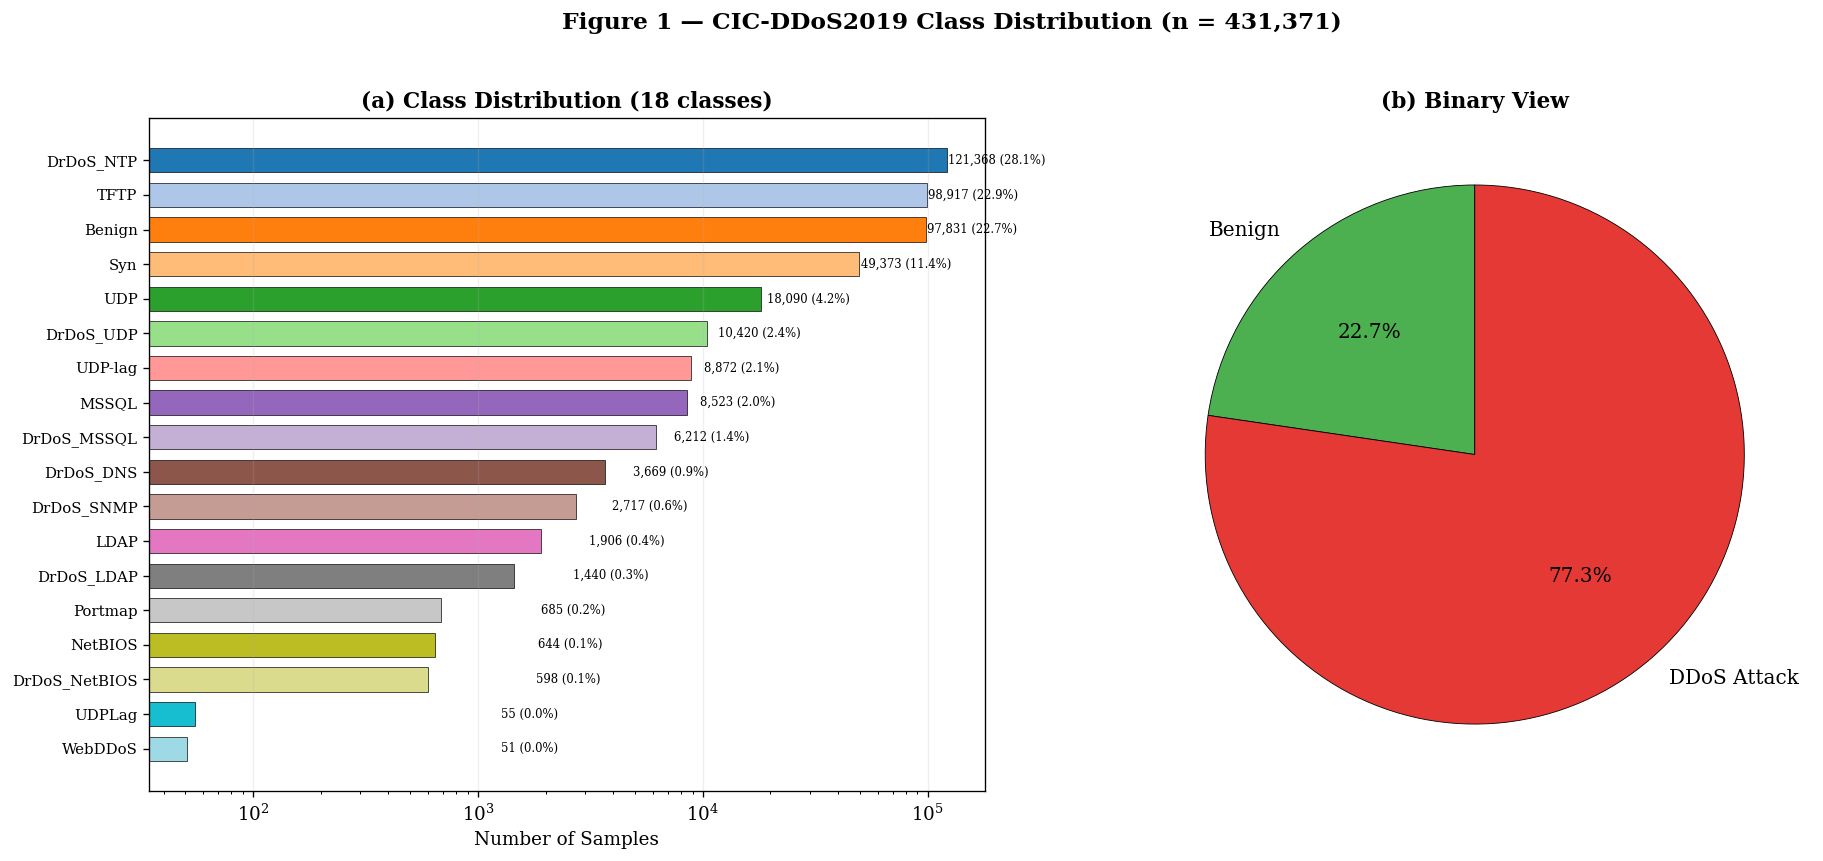

  ✅ Figure 1 saved.

  Generating Figure 2 — Attack Taxonomy ...


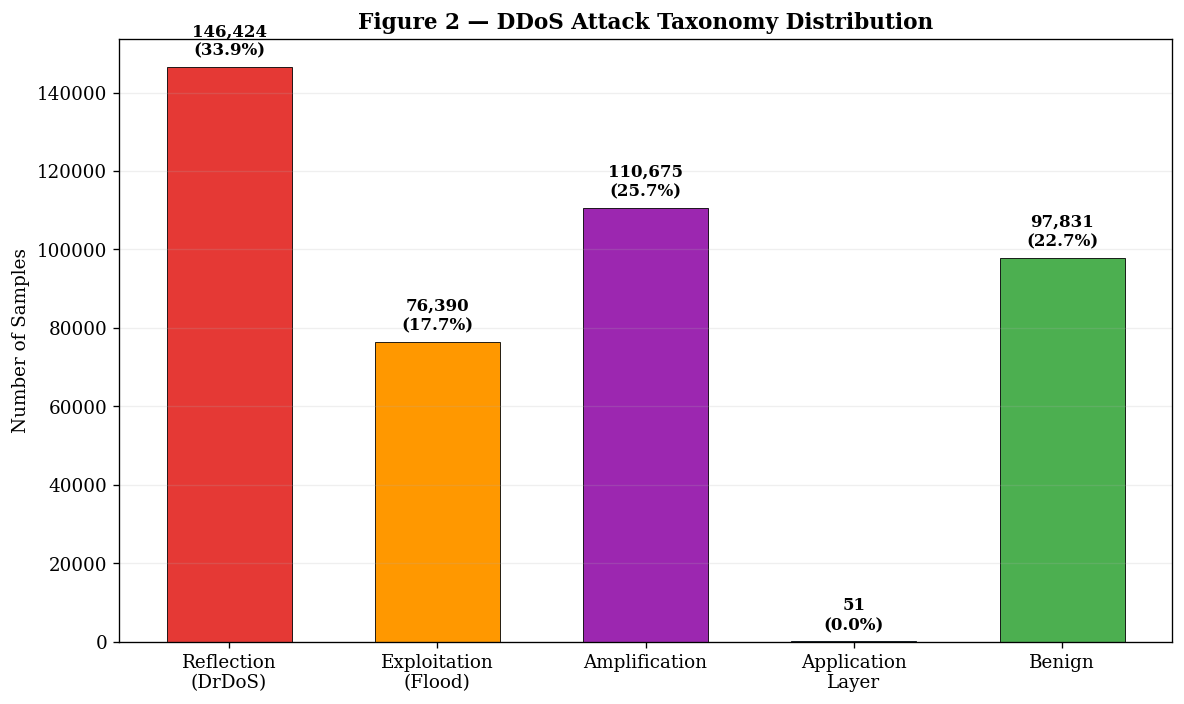

  ✅ Figure 2 saved.

  Generating Figure 3 — Train vs Test Split ...


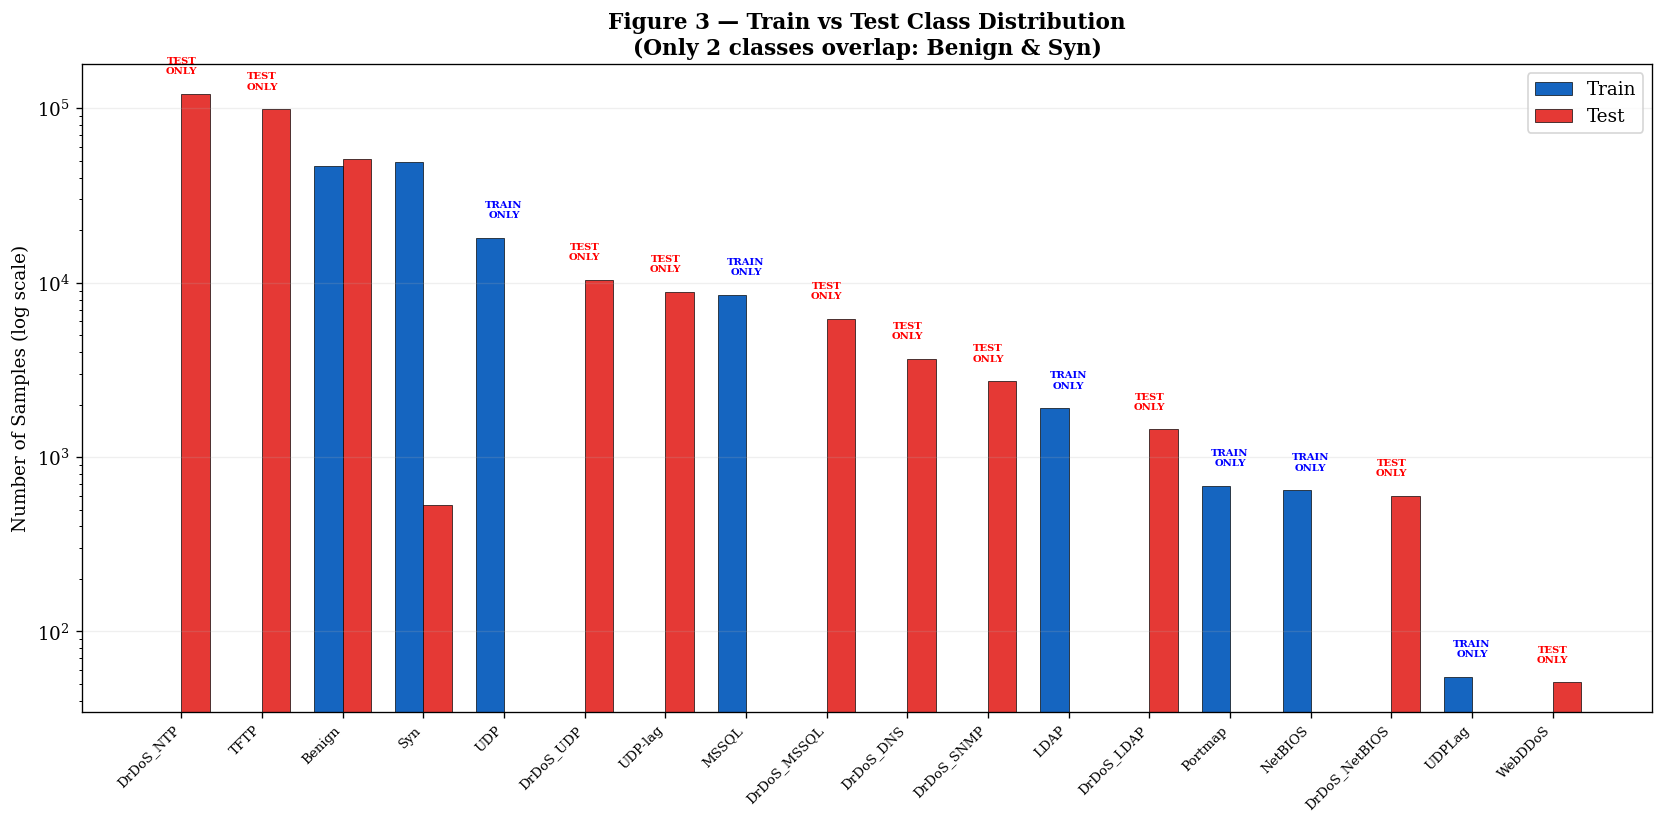

  ✅ Figure 3 saved.

  Generating Figure 4 — Protocol Distribution ...


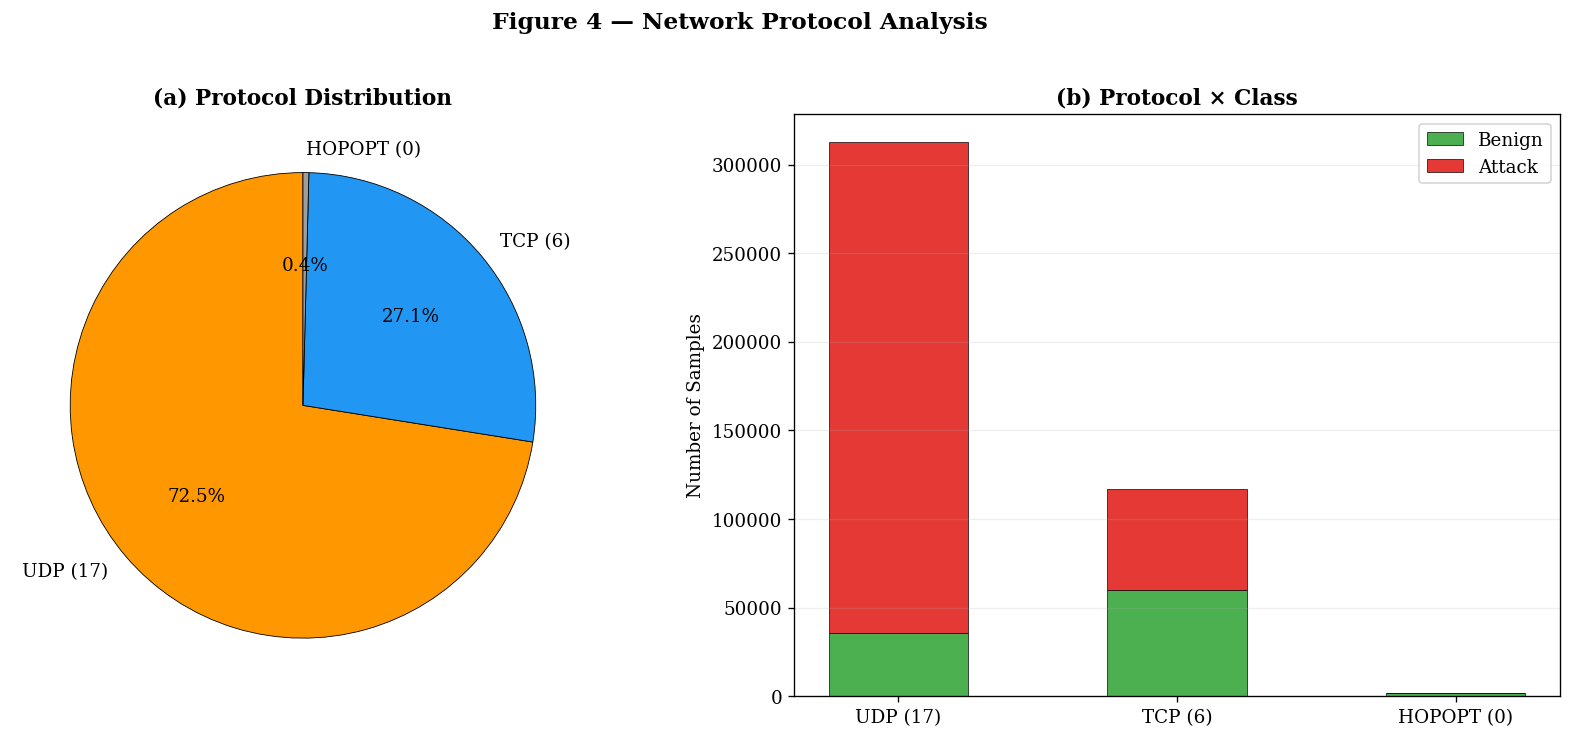

  ✅ Figure 4 saved.

  Generating Figure 5 — Feature Zero-Rate Distribution ...


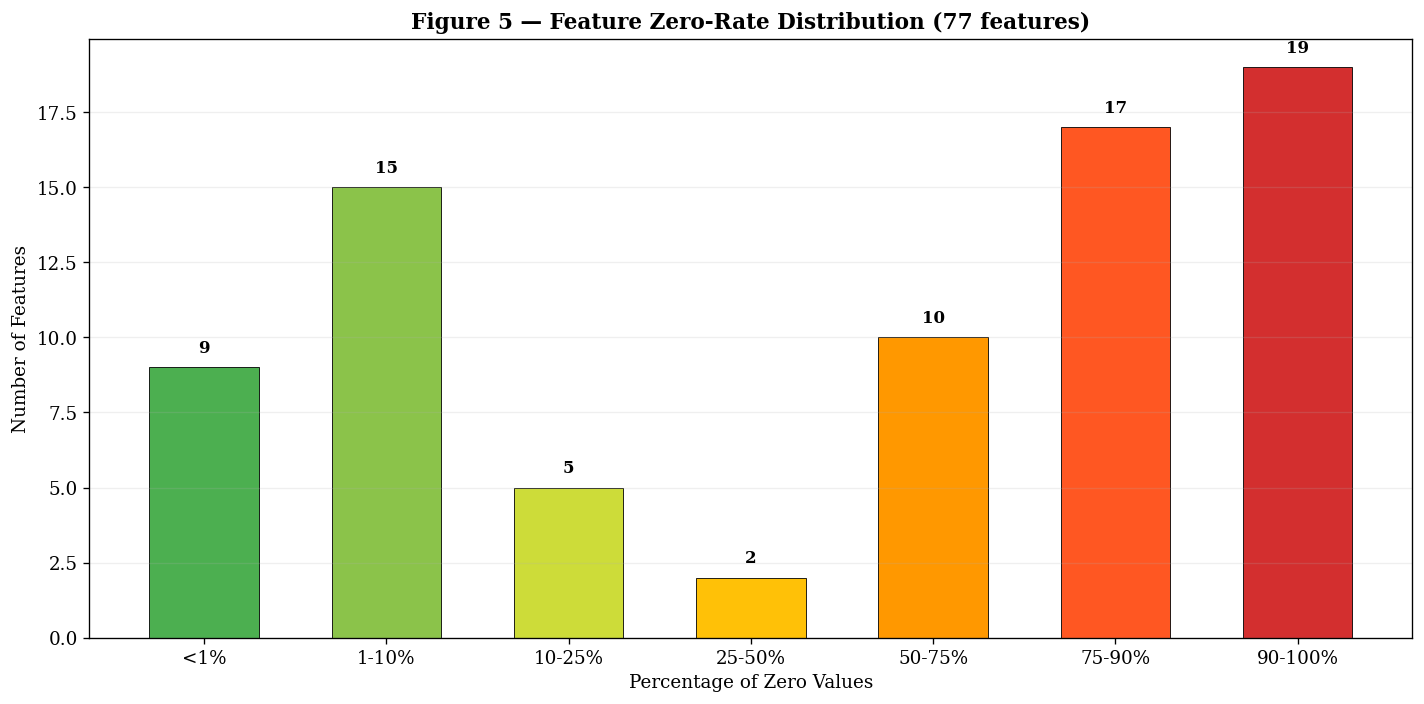

  ✅ Figure 5 saved.

  Generating Figure 6 — Feature Heatmap by Class ...


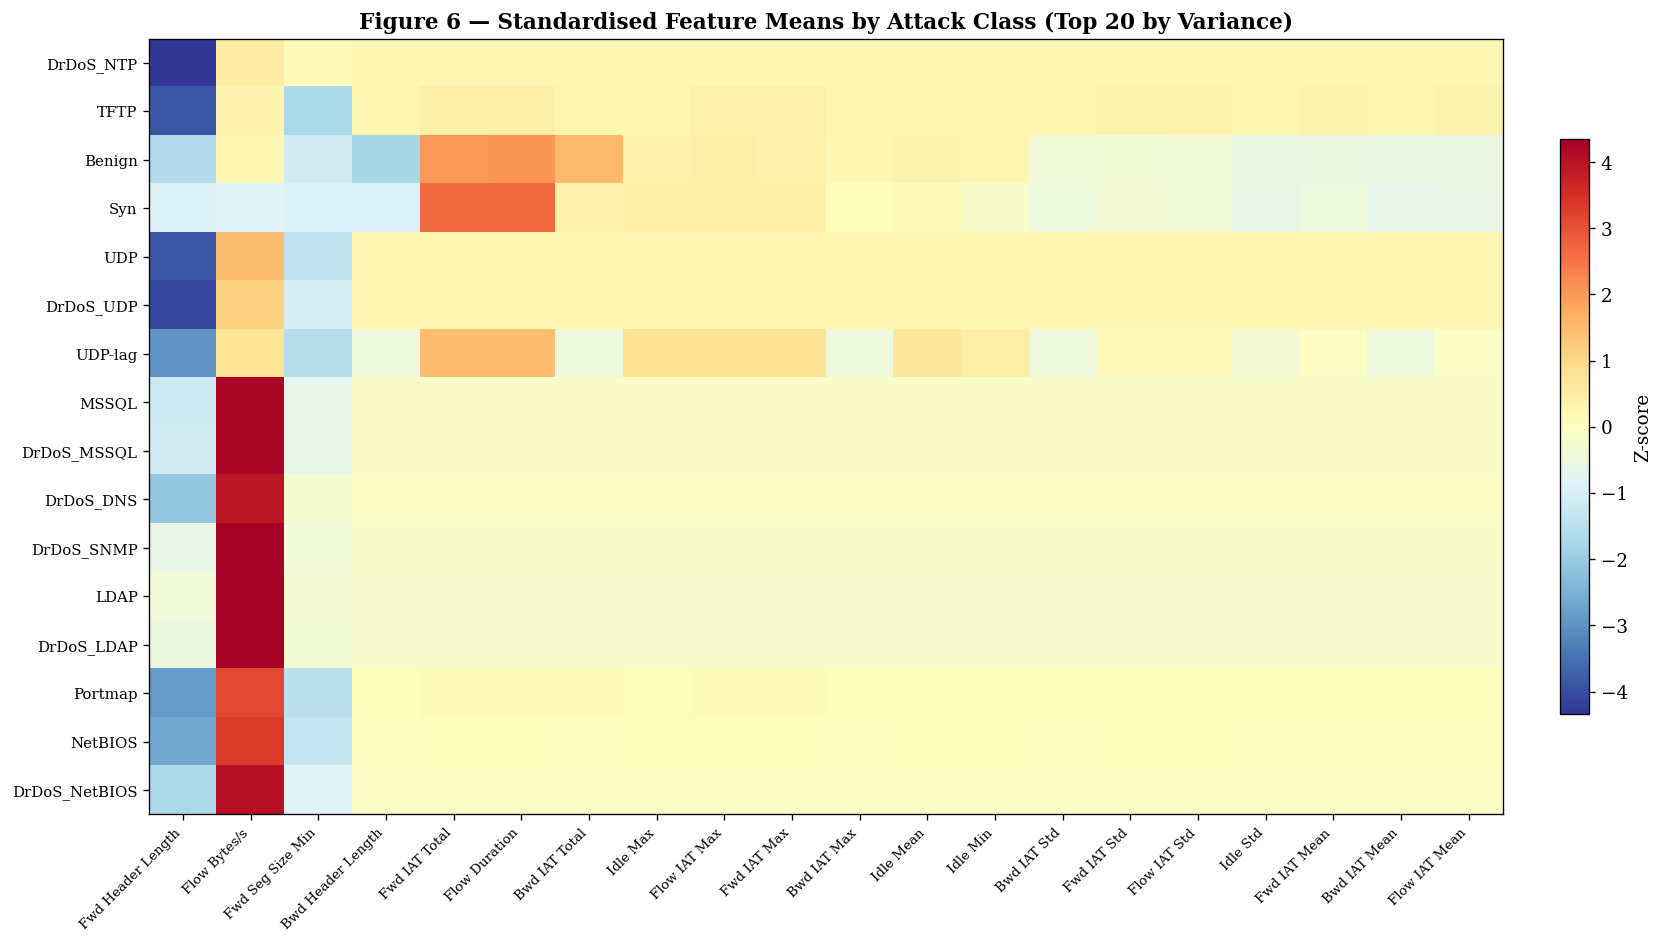

  ✅ Figure 6 saved.

  Generating Figure 7 — Flow Duration by Attack Type ...


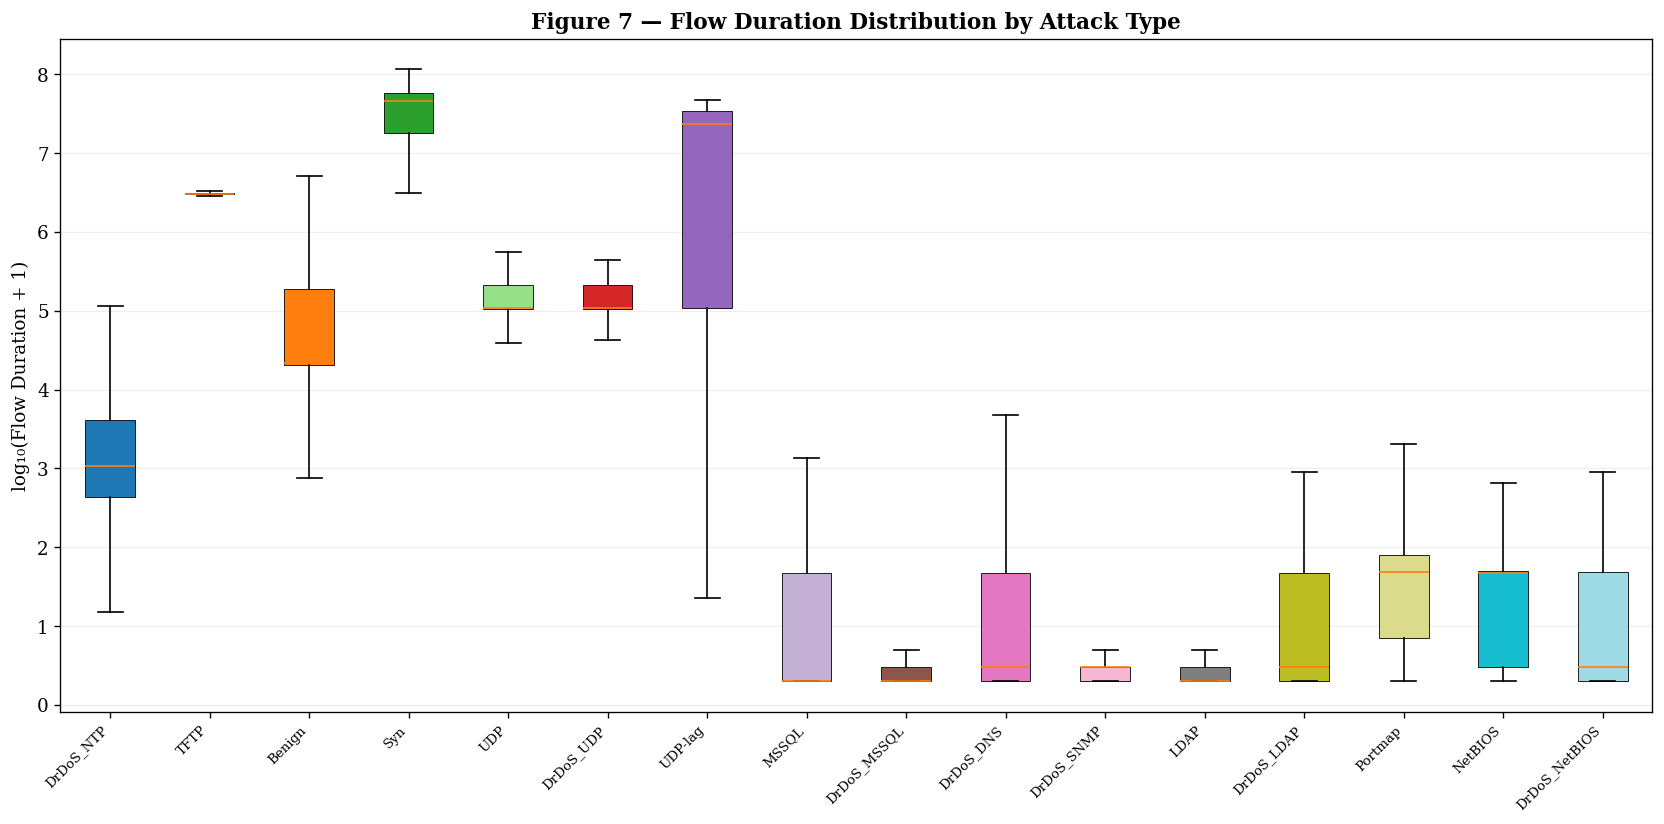

  ✅ Figure 7 saved.

  Generating Figure 8 — Correlation Matrix ...


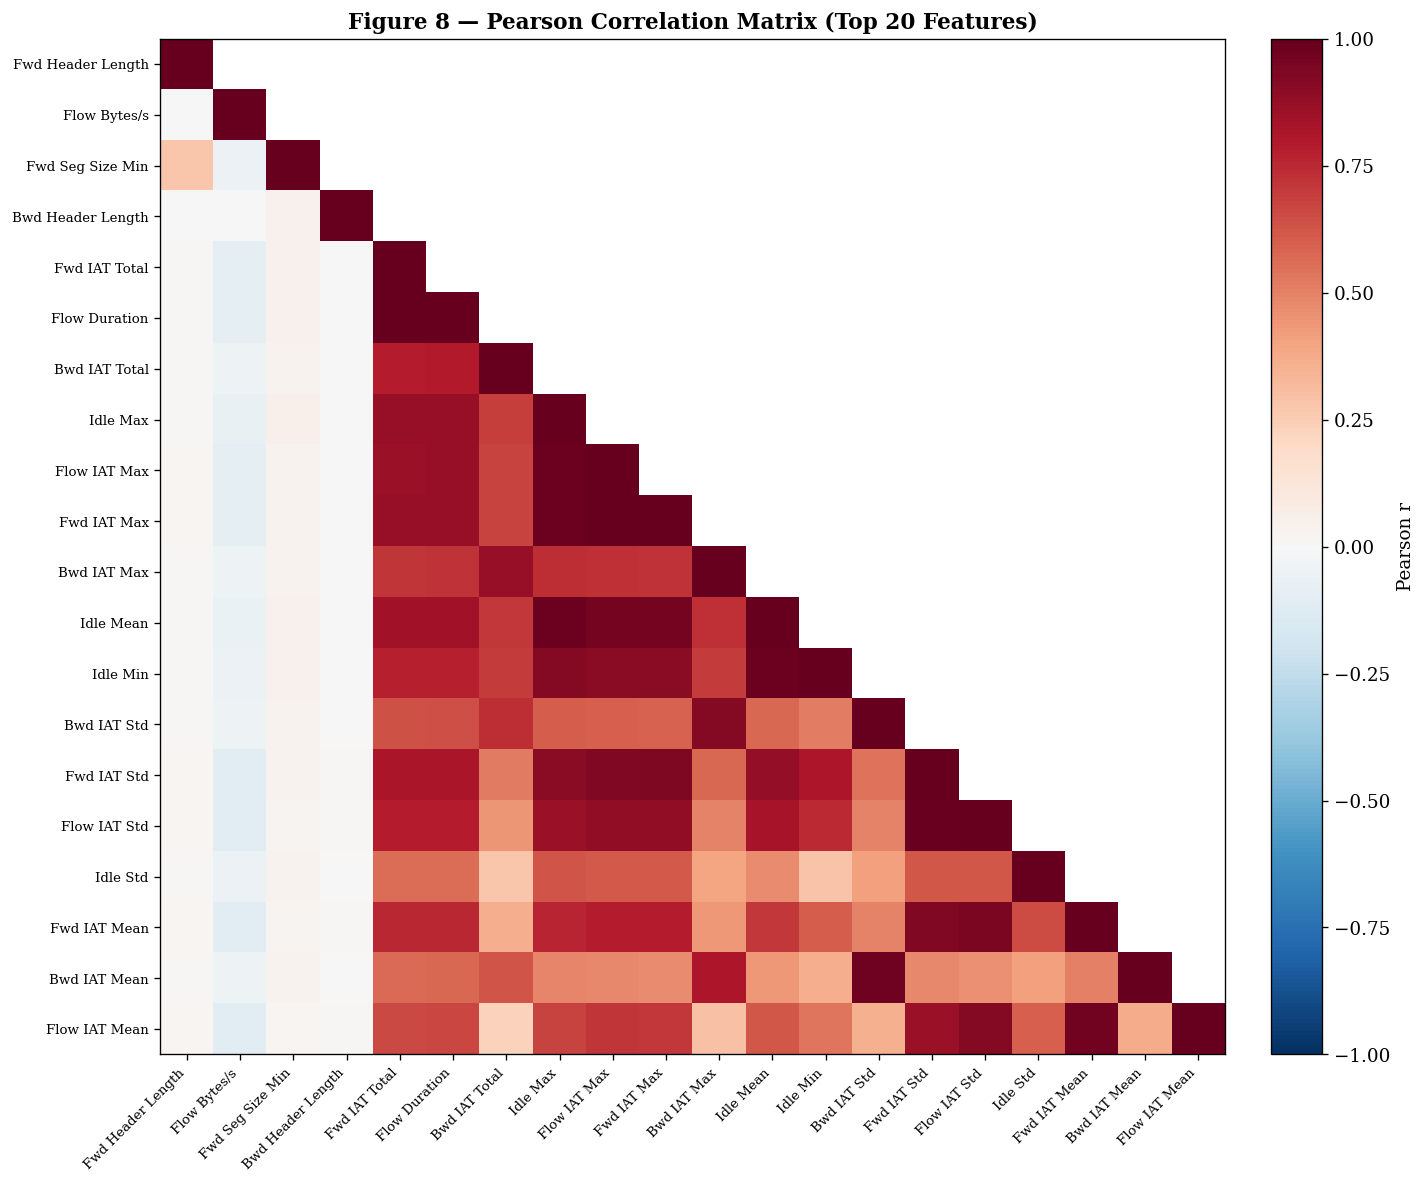

  ✅ Figure 8 saved.

  ALL 8 EDA FIGURES GENERATED AND SAVED
  ddos_fig1_class_distribution.png
  ddos_fig2_attack_taxonomy.png
  ddos_fig3_train_test_split.png
  ddos_fig4_protocol.png
  ddos_fig5_zero_rate.png
  ddos_fig6_feature_heatmap.png
  ddos_fig7_flow_duration.png
  ddos_fig8_correlation.png
  ✅ Ready for Cell 4 — Preprocessing & Balancing


In [3]:
# ══════════════════════════════════════════════════════════════════
# CELL 3 — EDA FIGURES (CIC-DDoS2019)
# ══════════════════════════════════════════════════════════════════
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np, pandas as pd, warnings
warnings.filterwarnings('ignore')

SAVE = '/content/drive/MyDrive/Colab Notebooks'
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'figure.dpi': 120, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'figure.facecolor': 'white'
})

print('='*70)
print('  CELL 3 — EDA FIGURES (CIC-DDoS2019)')
print('='*70)

meta_cols = ['Label', 'split', 'source_file']
feat_cols = [c for c in df_all.columns if c not in meta_cols]
vc = df_all['Label'].value_counts().sort_values(ascending=False)

# ═══════════════════════════════════════════════════════════
# FIGURE 1 — MULTI-CLASS DISTRIBUTION
# ═══════════════════════════════════════════════════════════
print('\n  Generating Figure 1 — Multi-Class Distribution ...')
fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(16, 7))

# Left: horizontal bar
colors_18 = plt.cm.tab20(np.linspace(0, 1, len(vc)))
bars = ax1a.barh(range(len(vc)), vc.values[::-1], color=colors_18[::-1],
                 edgecolor='black', linewidth=0.4, height=0.7)
ax1a.set_yticks(range(len(vc)))
ax1a.set_yticklabels(vc.index[::-1], fontsize=9)
ax1a.set_xlabel('Number of Samples')
ax1a.set_title('(a) Class Distribution (18 classes)', fontweight='bold')
for i, (cnt, cls) in enumerate(zip(vc.values[::-1], vc.index[::-1])):
    ax1a.text(cnt + max(vc.values)*0.01, i, f'{cnt:,} ({cnt/len(df_all)*100:.1f}%)',
              va='center', fontsize=7)
ax1a.set_xscale('log')
ax1a.grid(axis='x', alpha=0.2)

# Right: binary pie
n_benign = (df_all['Label'] == 'Benign').sum()
n_attack = len(df_all) - n_benign
ax1b.pie([n_benign, n_attack], labels=['Benign', 'DDoS Attack'],
         autopct='%1.1f%%', colors=['#4CAF50', '#E53935'],
         startangle=90, textprops={'fontsize': 12},
         wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
ax1b.set_title('(b) Binary View', fontweight='bold')

fig1.suptitle('Figure 1 — CIC-DDoS2019 Class Distribution (n = 431,371)',
              fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE}/ddos_fig1_class_distribution.png')
plt.show()
print('  ✅ Figure 1 saved.')

# ═══════════════════════════════════════════════════════════
# FIGURE 2 — ATTACK TAXONOMY (grouped)
# ═══════════════════════════════════════════════════════════
print('\n  Generating Figure 2 — Attack Taxonomy ...')
families = {
    'Reflection\n(DrDoS)': ['DrDoS_NTP','DrDoS_DNS','DrDoS_LDAP','DrDoS_MSSQL',
                            'DrDoS_NetBIOS','DrDoS_SNMP','DrDoS_UDP'],
    'Exploitation\n(Flood)': ['Syn','UDP','UDP-lag','UDPLag'],
    'Amplification': ['TFTP','MSSQL','LDAP','NetBIOS','Portmap'],
    'Application\nLayer': ['WebDDoS'],
    'Benign': ['Benign']
}
fam_counts = {}
for fam, members in families.items():
    fam_counts[fam] = sum(vc.get(m, 0) for m in members)

fig2, ax2 = plt.subplots(figsize=(10, 6))
fam_names = list(fam_counts.keys())
fam_vals  = list(fam_counts.values())
fam_colors = ['#E53935', '#FF9800', '#9C27B0', '#2196F3', '#4CAF50']

bars2 = ax2.bar(fam_names, fam_vals, color=fam_colors, edgecolor='black',
                linewidth=0.5, width=0.6)
for bar, val in zip(bars2, fam_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
             f'{val:,}\n({val/len(df_all)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Number of Samples')
ax2.set_title('Figure 2 — DDoS Attack Taxonomy Distribution', fontweight='bold')
ax2.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(f'{SAVE}/ddos_fig2_attack_taxonomy.png')
plt.show()
print('  ✅ Figure 2 saved.')

# ═══════════════════════════════════════════════════════════
# FIGURE 3 — TRAIN vs TEST CLASS DISTRIBUTION
# ═══════════════════════════════════════════════════════════
print('\n  Generating Figure 3 — Train vs Test Split ...')
all_classes = vc.index.tolist()
train_vc = df_train['Label'].value_counts()
test_vc  = df_test['Label'].value_counts()

fig3, ax3 = plt.subplots(figsize=(14, 7))
x3 = np.arange(len(all_classes))
w3 = 0.35

train_vals = [train_vc.get(c, 0) for c in all_classes]
test_vals  = [test_vc.get(c, 0) for c in all_classes]

ax3.bar(x3 - w3/2, train_vals, w3, label='Train', color='#1565C0',
        edgecolor='black', linewidth=0.4)
ax3.bar(x3 + w3/2, test_vals, w3, label='Test', color='#E53935',
        edgecolor='black', linewidth=0.4)

ax3.set_xticks(x3)
ax3.set_xticklabels(all_classes, rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Number of Samples (log scale)')
ax3.set_yscale('log')
ax3.set_title('Figure 3 — Train vs Test Class Distribution\n'
              '(Only 2 classes overlap: Benign & Syn)',
              fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.2)

# Annotate train-only and test-only
for i, cls in enumerate(all_classes):
    if train_vc.get(cls, 0) == 0 and test_vc.get(cls, 0) > 0:
        ax3.text(i, test_vc[cls]*1.3, 'TEST\nONLY', ha='center',
                 fontsize=6, color='red', fontweight='bold')
    elif test_vc.get(cls, 0) == 0 and train_vc.get(cls, 0) > 0:
        ax3.text(i, train_vc[cls]*1.3, 'TRAIN\nONLY', ha='center',
                 fontsize=6, color='blue', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE}/ddos_fig3_train_test_split.png')
plt.show()
print('  ✅ Figure 3 saved.')

# ═══════════════════════════════════════════════════════════
# FIGURE 4 — PROTOCOL DISTRIBUTION
# ═══════════════════════════════════════════════════════════
print('\n  Generating Figure 4 — Protocol Distribution ...')
proto_map = {6: 'TCP (6)', 17: 'UDP (17)', 0: 'HOPOPT (0)'}

fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(14, 6))

# Left: protocol pie
proto_vc = df_all['Protocol'].value_counts()
proto_labels = [proto_map.get(p, f'Proto-{p}') for p in proto_vc.index]
proto_colors = ['#FF9800', '#2196F3', '#9E9E9E']
ax4a.pie(proto_vc.values, labels=proto_labels, autopct='%1.1f%%',
         colors=proto_colors[:len(proto_vc)], startangle=90,
         textprops={'fontsize': 11},
         wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
ax4a.set_title('(a) Protocol Distribution', fontweight='bold')

# Right: stacked bar (protocol × benign/attack)
protos = proto_vc.index.tolist()
benign_by_proto = []
attack_by_proto = []
for p in protos:
    sub = df_all[df_all['Protocol'] == p]
    benign_by_proto.append((sub['Label'] == 'Benign').sum())
    attack_by_proto.append((sub['Label'] != 'Benign').sum())

x4 = np.arange(len(protos))
ax4b.bar(x4, benign_by_proto, label='Benign', color='#4CAF50',
         edgecolor='black', linewidth=0.4, width=0.5)
ax4b.bar(x4, attack_by_proto, bottom=benign_by_proto, label='Attack',
         color='#E53935', edgecolor='black', linewidth=0.4, width=0.5)
ax4b.set_xticks(x4)
ax4b.set_xticklabels([proto_map.get(p, str(p)) for p in protos])
ax4b.set_ylabel('Number of Samples')
ax4b.set_title('(b) Protocol × Class', fontweight='bold')
ax4b.legend()
ax4b.grid(axis='y', alpha=0.2)

fig4.suptitle('Figure 4 — Network Protocol Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE}/ddos_fig4_protocol.png')
plt.show()
print('  ✅ Figure 4 saved.')

# ═══════════════════════════════════════════════════════════
# FIGURE 5 — FEATURE ZERO-RATE DISTRIBUTION
# ═══════════════════════════════════════════════════════════
print('\n  Generating Figure 5 — Feature Zero-Rate Distribution ...')
zero_rates = []
for col in feat_cols:
    if df_all[col].dtype in ['int8','int16','int32','int64','float32','float64']:
        zr = (df_all[col] == 0).sum() / len(df_all) * 100
        zero_rates.append((col, zr))

zero_rates.sort(key=lambda x: x[1], reverse=True)
zr_vals = [z[1] for z in zero_rates]

fig5, ax5 = plt.subplots(figsize=(12, 6))
bins5 = [0, 1, 10, 25, 50, 75, 90, 100.01]
labels5 = ['<1%', '1-10%', '10-25%', '25-50%', '50-75%', '75-90%', '90-100%']
hist_vals = np.histogram(zr_vals, bins=bins5)[0]
colors5 = ['#4CAF50','#8BC34A','#CDDC39','#FFC107','#FF9800','#FF5722','#D32F2F']

ax5.bar(labels5, hist_vals, color=colors5, edgecolor='black', linewidth=0.5, width=0.6)
for i, v in enumerate(hist_vals):
    ax5.text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=10)
ax5.set_xlabel('Percentage of Zero Values')
ax5.set_ylabel('Number of Features')
ax5.set_title('Figure 5 — Feature Zero-Rate Distribution (77 features)', fontweight='bold')
ax5.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(f'{SAVE}/ddos_fig5_zero_rate.png')
plt.show()
print('  ✅ Figure 5 saved.')

# ═══════════════════════════════════════════════════════════
# FIGURE 6 — TOP 20 FEATURES: MEAN VALUE BY CLASS
# ═══════════════════════════════════════════════════════════
print('\n  Generating Figure 6 — Feature Heatmap by Class ...')
# Use top classes (>500 samples) for readability
top_classes = [c for c in vc.index if vc[c] >= 500]
num_feat_cols = [c for c in feat_cols
                 if df_all[c].dtype in ['int8','int16','int32','int64','float32','float64']]

# Select top 20 features by variance
feat_var = df_all[num_feat_cols].var().sort_values(ascending=False)
top20_var = feat_var.head(20).index.tolist()

# Compute mean per class (standardised for heatmap)
from sklearn.preprocessing import StandardScaler
means = df_all.groupby('Label')[top20_var].mean().loc[top_classes]
scaler_hm = StandardScaler()
means_sc = pd.DataFrame(scaler_hm.fit_transform(means.T).T,
                         index=means.index, columns=means.columns)

fig6, ax6 = plt.subplots(figsize=(14, 8))
im6 = ax6.imshow(means_sc.values, aspect='auto', cmap='RdYlBu_r')
ax6.set_xticks(range(len(top20_var)))
ax6.set_xticklabels(top20_var, rotation=45, ha='right', fontsize=8)
ax6.set_yticks(range(len(top_classes)))
ax6.set_yticklabels(top_classes, fontsize=9)
ax6.set_title('Figure 6 — Standardised Feature Means by Attack Class (Top 20 by Variance)',
              fontweight='bold')
plt.colorbar(im6, ax=ax6, fraction=0.02, pad=0.04, label='Z-score')
plt.tight_layout()
plt.savefig(f'{SAVE}/ddos_fig6_feature_heatmap.png')
plt.show()
print('  ✅ Figure 6 saved.')

# ═══════════════════════════════════════════════════════════
# FIGURE 7 — FLOW DURATION BY ATTACK TYPE
# ═══════════════════════════════════════════════════════════
print('\n  Generating Figure 7 — Flow Duration by Attack Type ...')
fig7, ax7 = plt.subplots(figsize=(14, 7))

# Log-transform for visibility
plot_data = []
plot_labels = []
for cls in top_classes:
    vals = df_all.loc[df_all['Label'] == cls, 'Flow Duration'].values
    vals = vals[vals > 0]
    if len(vals) > 5000:
        vals = np.random.choice(vals, 5000, replace=False)
    plot_data.append(np.log10(vals + 1))
    plot_labels.append(cls)

bp = ax7.boxplot(plot_data, labels=plot_labels, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], plt.cm.tab20(np.linspace(0, 1, len(plot_data)))):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.5)

ax7.set_xticklabels(plot_labels, rotation=45, ha='right', fontsize=8)
ax7.set_ylabel('log₁₀(Flow Duration + 1)')
ax7.set_title('Figure 7 — Flow Duration Distribution by Attack Type', fontweight='bold')
ax7.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(f'{SAVE}/ddos_fig7_flow_duration.png')
plt.show()
print('  ✅ Figure 7 saved.')

# ═══════════════════════════════════════════════════════════
# FIGURE 8 — CORRELATION MATRIX (Top 20 features)
# ═══════════════════════════════════════════════════════════
print('\n  Generating Figure 8 — Correlation Matrix ...')
sample_corr = df_all[top20_var].sample(min(50000, len(df_all)), random_state=42)
corr8 = sample_corr.corr()

fig8, ax8 = plt.subplots(figsize=(12, 10))
mask8 = np.triu(np.ones_like(corr8, dtype=bool), k=1)
corr_masked = corr8.copy()
corr_masked[mask8] = np.nan

im8 = ax8.imshow(corr_masked.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax8.set_xticks(range(len(top20_var)))
ax8.set_xticklabels(top20_var, rotation=45, ha='right', fontsize=8)
ax8.set_yticks(range(len(top20_var)))
ax8.set_yticklabels(top20_var, fontsize=8)
ax8.set_title('Figure 8 — Pearson Correlation Matrix (Top 20 Features)',
              fontweight='bold')
plt.colorbar(im8, ax=ax8, fraction=0.046, pad=0.04, label='Pearson r')
plt.tight_layout()
plt.savefig(f'{SAVE}/ddos_fig8_correlation.png')
plt.show()
print('  ✅ Figure 8 saved.')

# ═══════════════════════════════════════════════════════════
print(f'\n{"="*70}')
print(f'  ALL 8 EDA FIGURES GENERATED AND SAVED')
print(f'{"="*70}')
print(f'  ddos_fig1_class_distribution.png')
print(f'  ddos_fig2_attack_taxonomy.png')
print(f'  ddos_fig3_train_test_split.png')
print(f'  ddos_fig4_protocol.png')
print(f'  ddos_fig5_zero_rate.png')
print(f'  ddos_fig6_feature_heatmap.png')
print(f'  ddos_fig7_flow_duration.png')
print(f'  ddos_fig8_correlation.png')
print(f'{"="*70}')
print(f'  ✅ Ready for Cell 4 — Preprocessing & Balancing')
print(f'{"="*70}')


In [4]:
# ══════════════════════════════════════════════════════════════════
# CELL 4 — PREPROCESSING, FEATURE CLEANING & DATA PREPARATION
# ══════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd, time, warnings
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
warnings.filterwarnings('ignore')

t0 = time.time()
print('='*70)
print('  CELL 4 — PREPROCESSING & DATA PREPARATION')
print('='*70)

# ─────────────────────────────────────────────────────────
# 1 ▸ DROP CONSTANT FEATURES (12 identified in EDA)
# ─────────────────────────────────────────────────────────
print('\n[1] Dropping constant features ...')
const_cols = [c for c in feat_cols
              if df_all[c].nunique() <= 1]
print(f'    Constant features ({len(const_cols)}): {const_cols}')

# ─────────────────────────────────────────────────────────
# 2 ▸ DROP PERFECTLY REDUNDANT FEATURES (r = 1.0)
# ─────────────────────────────────────────────────────────
print(f'\n[2] Dropping perfectly redundant features (r = 1.0) ...')
redundant_drop = [
    'Subflow Fwd Packets',
    'Subflow Bwd Packets',
    'Subflow Fwd Bytes',
    'Subflow Bwd Bytes',
    'Avg Fwd Segment Size',
    'Avg Bwd Segment Size',
]
print(f'    Redundant features ({len(redundant_drop)}): {redundant_drop}')

# ─────────────────────────────────────────────────────────
# 3 ▸ DROP NEAR-CONSTANT (SYN Flag Count — 99.9% zeros)
# ─────────────────────────────────────────────────────────
near_const_drop = ['SYN Flag Count']
print(f'\n[3] Dropping near-constant: {near_const_drop}')

# ─────────────────────────────────────────────────────────
# 4 ▸ BUILD CLEAN FEATURE SET  ── FIXED: exclude targets
# ─────────────────────────────────────────────────────────
all_drop = set(
    const_cols + redundant_drop + near_const_drop +
    ['Label', 'split', 'source_file',
     'target_binary', 'target_multi']          # ← FIX: exclude target columns
)
clean_feat_cols = [c for c in df_all.columns if c not in all_drop]

print(f'\n[4] Feature set:')
print(f'    Original features  : {len(feat_cols)}')
print(f'    Dropped constant   : {len(const_cols)}')
print(f'    Dropped redundant  : {len(redundant_drop)}')
print(f'    Dropped near-const : {len(near_const_drop)}')
print(f'    Dropped targets    : target_binary, target_multi')
print(f'    Remaining features : {len(clean_feat_cols)}')

# ─── Safety check: no target leakage ───
assert 'target_binary' not in clean_feat_cols, 'LEAKAGE: target_binary in features!'
assert 'target_multi'  not in clean_feat_cols, 'LEAKAGE: target_multi in features!'
assert 'Label'         not in clean_feat_cols, 'LEAKAGE: Label in features!'
print(f'    ✅ No target leakage confirmed')

# ─────────────────────────────────────────────────────────
# 5 ▸ CREATE BINARY TARGET (Benign=0, Attack=1)
#     AND MULTI-CLASS TARGET
# ─────────────────────────────────────────────────────────
print(f'\n[5] Encoding targets ...')
df_all['target_binary'] = (df_all['Label'] != 'Benign').astype(int)

le = LabelEncoder()
df_all['target_multi'] = le.fit_transform(df_all['Label'])
class_names = le.classes_
print(f'    Binary  : 0=Benign, 1=Attack')
print(f'    Multi   : {len(class_names)} classes')
for i, cn in enumerate(class_names):
    cnt = (df_all['target_multi'] == i).sum()
    print(f'      {i:>2} = {cn:<25} ({cnt:,})')

# ─────────────────────────────────────────────────────────
# 6 ▸ USE ORIGINAL TRAIN/TEST SPLIT
# ─────────────────────────────────────────────────────────
print(f'\n[6] Using original train/test split ...')

train_mask = df_all['split'] == 'train'
test_mask  = df_all['split'] == 'test'

X_train_raw = df_all.loc[train_mask, clean_feat_cols].values.astype(np.float64)
X_test_raw  = df_all.loc[test_mask, clean_feat_cols].values.astype(np.float64)

y_train_bin = df_all.loc[train_mask, 'target_binary'].values
y_test_bin  = df_all.loc[test_mask, 'target_binary'].values

y_train_multi = df_all.loc[train_mask, 'target_multi'].values
y_test_multi  = df_all.loc[test_mask, 'target_multi'].values

print(f'    Train : {X_train_raw.shape[0]:,} × {X_train_raw.shape[1]} features')
print(f'    Test  : {X_test_raw.shape[0]:,} × {X_test_raw.shape[1]} features')

# ─── Double-check feature count matches ───
print(f'    Feature list sample: {clean_feat_cols[:5]} ...')
print(f'    X_train shape: {X_train_raw.shape}')

# ─────────────────────────────────────────────────────────
# 7 ▸ HANDLE INF / NaN (safety check)
# ─────────────────────────────────────────────────────────
print(f'\n[7] Handling Inf/NaN ...')
n_inf_train = np.isinf(X_train_raw).sum()
n_inf_test  = np.isinf(X_test_raw).sum()
n_nan_train = np.isnan(X_train_raw).sum()
n_nan_test  = np.isnan(X_test_raw).sum()
print(f'    Train Inf: {n_inf_train}, NaN: {n_nan_train}')
print(f'    Test  Inf: {n_inf_test}, NaN: {n_nan_test}')

for i in range(X_train_raw.shape[1]):
    col_tr = X_train_raw[:, i]
    finite_mask = np.isfinite(col_tr)
    if not finite_mask.all():
        col_max = np.nanmax(col_tr[finite_mask]) if finite_mask.any() else 0
        col_tr[~finite_mask] = col_max
    col_ts = X_test_raw[:, i]
    finite_mask_ts = np.isfinite(col_ts)
    if not finite_mask_ts.all():
        col_max_ts = np.nanmax(col_tr[finite_mask]) if finite_mask.any() else 0
        col_ts[~finite_mask_ts] = col_max_ts

X_train_raw = np.nan_to_num(X_train_raw, nan=0.0)
X_test_raw  = np.nan_to_num(X_test_raw, nan=0.0)
print(f'    After fix — Inf: {np.isinf(X_train_raw).sum() + np.isinf(X_test_raw).sum()}, '
      f'NaN: {np.isnan(X_train_raw).sum() + np.isnan(X_test_raw).sum()}')

# ─────────────────────────────────────────────────────────
# 8 ▸ CREATE VALIDATION SPLIT FROM TRAIN (80/20)
# ─────────────────────────────────────────────────────────
print(f'\n[8] Creating validation split (80/20 from train) ...')
from sklearn.model_selection import train_test_split

X_train, X_val, y_tr_bin, y_val_bin, y_tr_multi, y_val_multi = train_test_split(
    X_train_raw, y_train_bin, y_train_multi,
    test_size=0.20, stratify=y_train_bin, random_state=42
)

print(f'    Train : {X_train.shape[0]:,}  (Benign: {(y_tr_bin==0).sum():,} | Attack: {(y_tr_bin==1).sum():,})')
print(f'    Val   : {X_val.shape[0]:,}  (Benign: {(y_val_bin==0).sum():,} | Attack: {(y_val_bin==1).sum():,})')
print(f'    Test  : {X_test_raw.shape[0]:,}  (Benign: {(y_test_bin==0).sum():,} | Attack: {(y_test_bin==1).sum():,})')

# ─────────────────────────────────────────────────────────
# 9 ▸ BALANCE TRAINING SET (SMOTE for binary)
# ─────────────────────────────────────────────────────────
print(f'\n[9] SMOTE balancing (binary):')
print(f'    Before: Benign={np.sum(y_tr_bin==0):,}, Attack={np.sum(y_tr_bin==1):,}')

smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_tr_bin)

print(f'    After : Benign={np.sum(y_train_bal==0):,}, Attack={np.sum(y_train_bal==1):,}')
print(f'    Total : {len(X_train_bal):,}')

# ─────────────────────────────────────────────────────────
# 10 ▸ FEATURE SCALING
# ─────────────────────────────────────────────────────────
print(f'\n[10] StandardScaler: fit on balanced train ...')
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test_raw)

print(f'     Train — mean: {X_train_sc.mean():.6f}, std: {X_train_sc.std():.4f}')
print(f'     Val   — mean: {X_val_sc.mean():.6f}, std: {X_val_sc.std():.4f}')
print(f'     Test  — mean: {X_test_sc.mean():.6f}, std: {X_test_sc.std():.4f}')

# ─────────────────────────────────────────────────────────
# Store feature names and references
# ─────────────────────────────────────────────────────────
feat_names = clean_feat_cols
y_test_multi_labels = df_all.loc[test_mask, 'Label'].values

# ─────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────
elapsed = time.time() - t0
print(f'\n{"="*70}')
print(f'  PREPROCESSING SUMMARY')
print(f'{"="*70}')
print(f'  Original features     : {len(feat_cols)}')
print(f'  Dropped (const+redun) : {len(const_cols) + len(redundant_drop) + len(near_const_drop)}')
print(f'  Final features        : {len(feat_names)}')
print(f'  Train (raw)           : {X_train_raw.shape[0]:,}')
print(f'  Train (balanced)      : {len(X_train_bal):,}')
print(f'  Validation            : {len(X_val):,}')
print(f'  Test                  : {len(X_test_raw):,}')
print(f'  Binary target         : 0=Benign, 1=Attack')
print(f'  Multi-class target    : {len(class_names)} classes')
print(f'  Balancing             : SMOTE (binary, k=5)')
print(f'  Scaler                : StandardScaler')
print(f'  Inf/NaN               : cleaned')
print(f'  Leakage check         : ✅ PASSED')
print(f'  Time                  : {elapsed:.1f}s')
print(f'{"="*70}')
print(f'  ✅ Ready for Cell 5 — Model Training')
print(f'{"="*70}')


  CELL 4 — PREPROCESSING & DATA PREPARATION

[1] Dropping constant features ...
    Constant features (12): ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'PSH Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

[2] Dropping perfectly redundant features (r = 1.0) ...
    Redundant features (6): ['Subflow Fwd Packets', 'Subflow Bwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Bytes', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size']

[3] Dropping near-constant: ['SYN Flag Count']

[4] Feature set:
    Original features  : 77
    Dropped constant   : 12
    Dropped redundant  : 6
    Dropped near-const : 1
    Dropped targets    : target_binary, target_multi
    Remaining features : 58
    ✅ No target leakage confirmed

[5] Encoding targets ...
    Binary  : 0=Benign, 1=Attack
    Multi   : 18 classes
       0 = Benign                    (97,831)
       1 

In [5]:
# ════════════════════════════════════════════════════════════════════
#  CELL 5 — MODEL TRAINING  (Binary: Benign vs Attack)
#  Method: Fixed temporal split (Day 1 train → Day 2 test)
#  No cross-validation — respects the zero-day evaluation protocol
# ════════════════════════════════════════════════════════════════════

import numpy as np, time, warnings
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix)
warnings.filterwarnings('ignore')

print('='*70)
print('  CELL 5 — MODEL TRAINING (Binary Classification)')
print('  Protocol : Temporal split (train=Day1, test=Day2 zero-day)')
print(f'  Train    : {X_train_sc.shape[0]:,} × {X_train_sc.shape[1]} (SMOTE-balanced)')
print(f'  Val      : {X_val_sc.shape[0]:,} × {X_val_sc.shape[1]}')
print(f'  Test     : {X_test_sc.shape[0]:,} × {X_test_sc.shape[1]}')
print('='*70)

# ── Anti-leakage check ──────────────────────────────────────────────
assert X_train_sc.shape[1] == len(feat_names), \
    f'LEAKAGE? Expected {len(feat_names)} features, got {X_train_sc.shape[1]}'
for bad_col in ['target_binary', 'target_multi', 'Label']:
    assert bad_col not in feat_names, f'LEAKAGE: {bad_col} found in features!'
print(f'  ✅ Leakage check passed ({len(feat_names)} features, no targets)')

# ── Define models ────────────────────────────────────────────────────
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=25, min_samples_split=5,
        min_samples_leaf=2, max_features='sqrt',
        class_weight='balanced', random_state=42, n_jobs=-1),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        subsample=0.8, min_samples_split=5,
        random_state=42),

    'Linear SVM': LinearSVC(
        C=1.0, max_iter=5000, class_weight='balanced',
        random_state=42, dual=True),

    'MLP Neural Network': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), activation='relu',
        solver='adam', alpha=0.001, batch_size=512,
        learning_rate='adaptive', learning_rate_init=0.001,
        max_iter=200, early_stopping=True, validation_fraction=0.1,
        random_state=42)
}

# ── Train & evaluate ────────────────────────────────────────────────
results = {}

for name, model in models.items():
    print(f'\n{"─"*70}')
    print(f'  Training: {name}')
    print(f'{"─"*70}')

    # --- Fit ---
    t_fit = time.time()
    model.fit(X_train_sc, y_train_bal)
    fit_time = time.time() - t_fit
    print(f'  Fit time: {fit_time:.1f}s')

    # --- Validation predictions ---
    y_val_pred = model.predict(X_val_sc)
    if hasattr(model, 'predict_proba'):
        y_val_proba = model.predict_proba(X_val_sc)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_val_proba = model.decision_function(X_val_sc)
    else:
        y_val_proba = y_val_pred.astype(float)

    val_acc  = accuracy_score(y_val_bin, y_val_pred)
    val_f1   = f1_score(y_val_bin, y_val_pred)
    val_prec = precision_score(y_val_bin, y_val_pred)
    val_rec  = recall_score(y_val_bin, y_val_pred)
    val_auc  = roc_auc_score(y_val_bin, y_val_proba)
    val_cm   = confusion_matrix(y_val_bin, y_val_pred)

    print(f'\n  VALIDATION ({X_val_sc.shape[0]:,} samples):')
    print(f'    Accuracy  : {val_acc:.4f}')
    print(f'    F1-score  : {val_f1:.4f}')
    print(f'    Precision : {val_prec:.4f}')
    print(f'    Recall    : {val_rec:.4f}')
    print(f'    ROC-AUC   : {val_auc:.4f}')
    print(f'    Confusion : TN={val_cm[0,0]:,} FP={val_cm[0,1]:,} '
          f'FN={val_cm[1,0]:,} TP={val_cm[1,1]:,}')

    # --- Test predictions ---
    y_test_pred = model.predict(X_test_sc)
    if hasattr(model, 'predict_proba'):
        y_test_proba = model.predict_proba(X_test_sc)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_test_proba = model.decision_function(X_test_sc)
    else:
        y_test_proba = y_test_pred.astype(float)

    test_acc  = accuracy_score(y_test_bin, y_test_pred)
    test_f1   = f1_score(y_test_bin, y_test_pred)
    test_prec = precision_score(y_test_bin, y_test_pred)
    test_rec  = recall_score(y_test_bin, y_test_pred)
    test_auc  = roc_auc_score(y_test_bin, y_test_proba)
    test_cm   = confusion_matrix(y_test_bin, y_test_pred)

    print(f'\n  TEST ({X_test_sc.shape[0]:,} samples — zero-day):')
    print(f'    Accuracy  : {test_acc:.4f}')
    print(f'    F1-score  : {test_f1:.4f}')
    print(f'    Precision : {test_prec:.4f}')
    print(f'    Recall    : {test_rec:.4f}')
    print(f'    ROC-AUC   : {test_auc:.4f}')
    print(f'    Confusion : TN={test_cm[0,0]:,} FP={test_cm[0,1]:,} '
          f'FN={test_cm[1,0]:,} TP={test_cm[1,1]:,}')

    # --- Generalization gap ---
    gap = abs(val_acc - test_acc)
    status = '✅ OK' if gap < 0.05 else '⚠️ GAP'
    print(f'\n  Generalization Δ(val→test): {gap:.4f}  {status}')

    # --- Store ---
    results[name] = {
        'model': model, 'fit_time': fit_time,
        'val': {'acc': val_acc, 'f1': val_f1, 'prec': val_prec,
                'rec': val_rec, 'auc': val_auc, 'cm': val_cm,
                'y_pred': y_val_pred, 'y_proba': y_val_proba},
        'test': {'acc': test_acc, 'f1': test_f1, 'prec': test_prec,
                 'rec': test_rec, 'auc': test_auc, 'cm': test_cm,
                 'y_pred': y_test_pred, 'y_proba': y_test_proba},
        'gap': gap
    }

# ── Comparison table ────────────────────────────────────────────────
print(f'\n{"="*70}')
print(f'  MODEL COMPARISON (sorted by Test F1)')
print(f'{"="*70}')
header = f'  {"Model":<22} {"Val F1":>8} {"Val AUC":>8} {"Test F1":>8} {"Test AUC":>8} {"Δ":>6} {"Time":>7}'
print(header)
print(f'  {"-"*67}')
for name, r in sorted(results.items(), key=lambda x: x[1]['test']['f1'], reverse=True):
    print(f'  {name:<22} {r["val"]["f1"]:>8.4f} {r["val"]["auc"]:>8.4f} '
          f'{r["test"]["f1"]:>8.4f} {r["test"]["auc"]:>8.4f} '
          f'{r["gap"]:>6.4f} {r["fit_time"]:>6.1f}s')

# ── Best model ──────────────────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]['test']['f1'])
best_model = results[best_name]['model']
best_r = results[best_name]
print(f'\n  🏆 Best model (Test F1): {best_name}')
print(f'     Test Accuracy  : {best_r["test"]["acc"]:.4f}')
print(f'     Test F1-score  : {best_r["test"]["f1"]:.4f}')
print(f'     Test Precision : {best_r["test"]["prec"]:.4f}')
print(f'     Test Recall    : {best_r["test"]["rec"]:.4f}')
print(f'     Test ROC-AUC   : {best_r["test"]["auc"]:.4f}')
print(f'     Fit time       : {best_r["fit_time"]:.1f}s')

# ── Per-attack-type analysis (best model on test set) ───────────────
print(f'\n{"="*70}')
print(f'  PER-ATTACK-TYPE ANALYSIS (Best model: {best_name})')
print(f'{"="*70}')
y_test_pred_best = best_r['test']['y_pred']
test_labels = df_all.loc[test_mask, 'Label'].values

print(f'  {"Attack Type":<22} {"Count":>8} {"Correct":>8} {"Detect Rate":>12}')
print(f'  {"-"*52}')
for label in sorted(set(test_labels)):
    mask_label = (test_labels == label)
    n_total = mask_label.sum()
    pred_bin = y_test_pred_best[mask_label]
    if label == 'Benign':
        correct = (pred_bin == 0).sum()
    else:
        correct = (pred_bin == 1).sum()
    print(f'  {label:<22} {n_total:>8,} {correct:>8,} {correct/n_total:>12.4f}')

elapsed_total = sum(r['fit_time'] for r in results.values())
print(f'\n  Total training time: {elapsed_total:.1f}s')
print(f'{"="*70}')
print(f'  ✅ Ready for Cell 6 — Evaluation Figures')
print(f'{"="*70}')


  CELL 5 — MODEL TRAINING (Binary Classification)
  Protocol : Temporal split (train=Day1, test=Day2 zero-day)
  Train    : 125,988 × 58 (SMOTE-balanced)
  Val      : 25,034 × 58
  Test     : 306,201 × 58
  ✅ Leakage check passed (58 features, no targets)

──────────────────────────────────────────────────────────────────────
  Training: Random Forest
──────────────────────────────────────────────────────────────────────
  Fit time: 87.2s

  VALIDATION (25,034 samples):
    Accuracy  : 0.9992
    F1-score  : 0.9994
    Precision : 0.9999
    Recall    : 0.9988
    ROC-AUC   : 1.0000
    Confusion : TN=9,284 FP=1 FN=19 TP=15,730

  TEST (306,201 samples — zero-day):
    Accuracy  : 0.9661
    F1-score  : 0.9792
    Precision : 0.9998
    Recall    : 0.9595
    ROC-AUC   : 0.9982
    Confusion : TN=51,355 FP=49 FN=10,325 TP=244,472

  Generalization Δ(val→test): 0.0331  ✅ OK

──────────────────────────────────────────────────────────────────────
  Training: Gradient Boosting
────────────

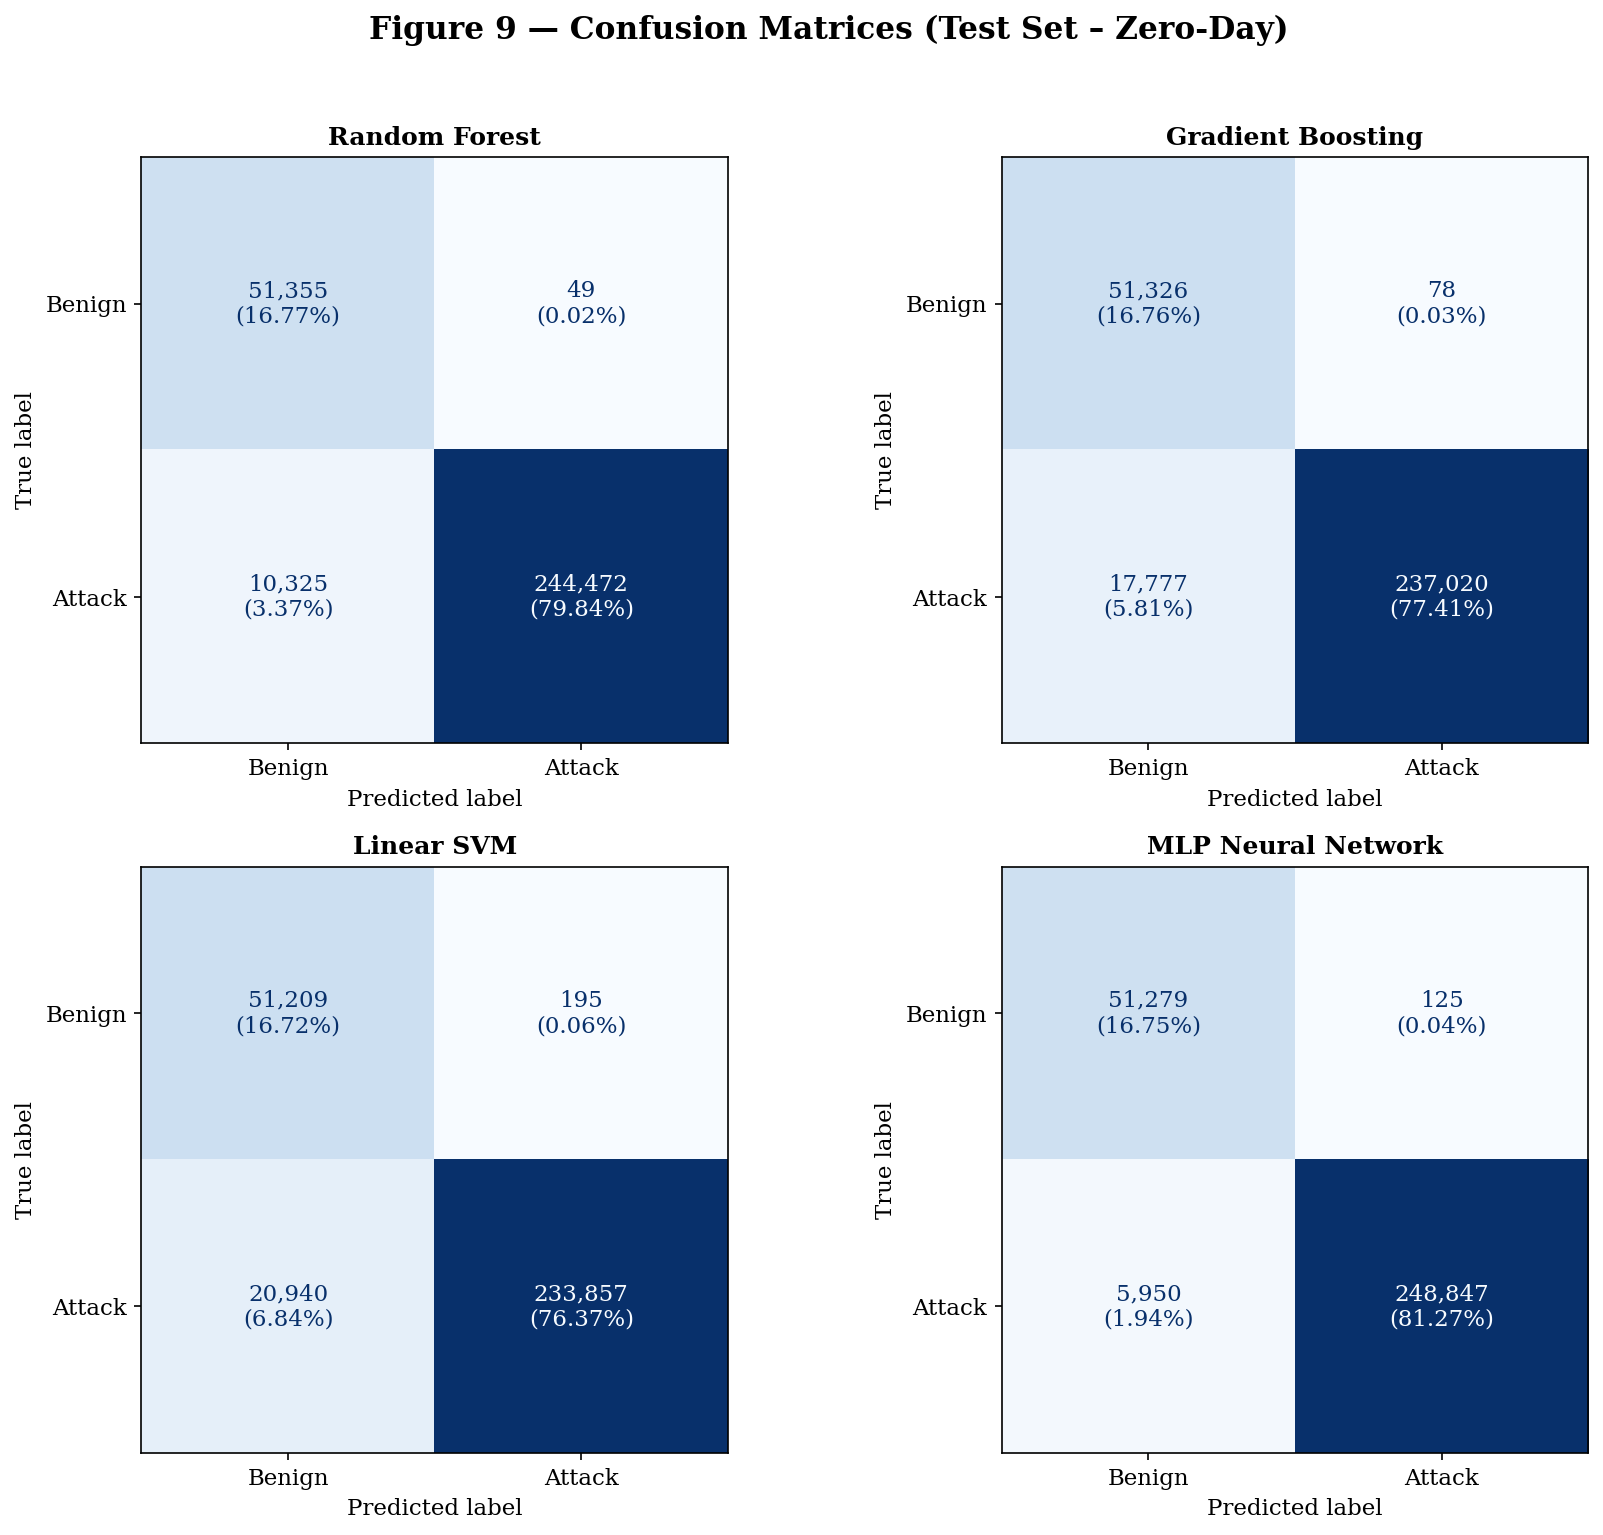

  ✅ Saved: /content/drive/MyDrive/Colab Notebooks/ddos_fig9_confusion_matrices.png


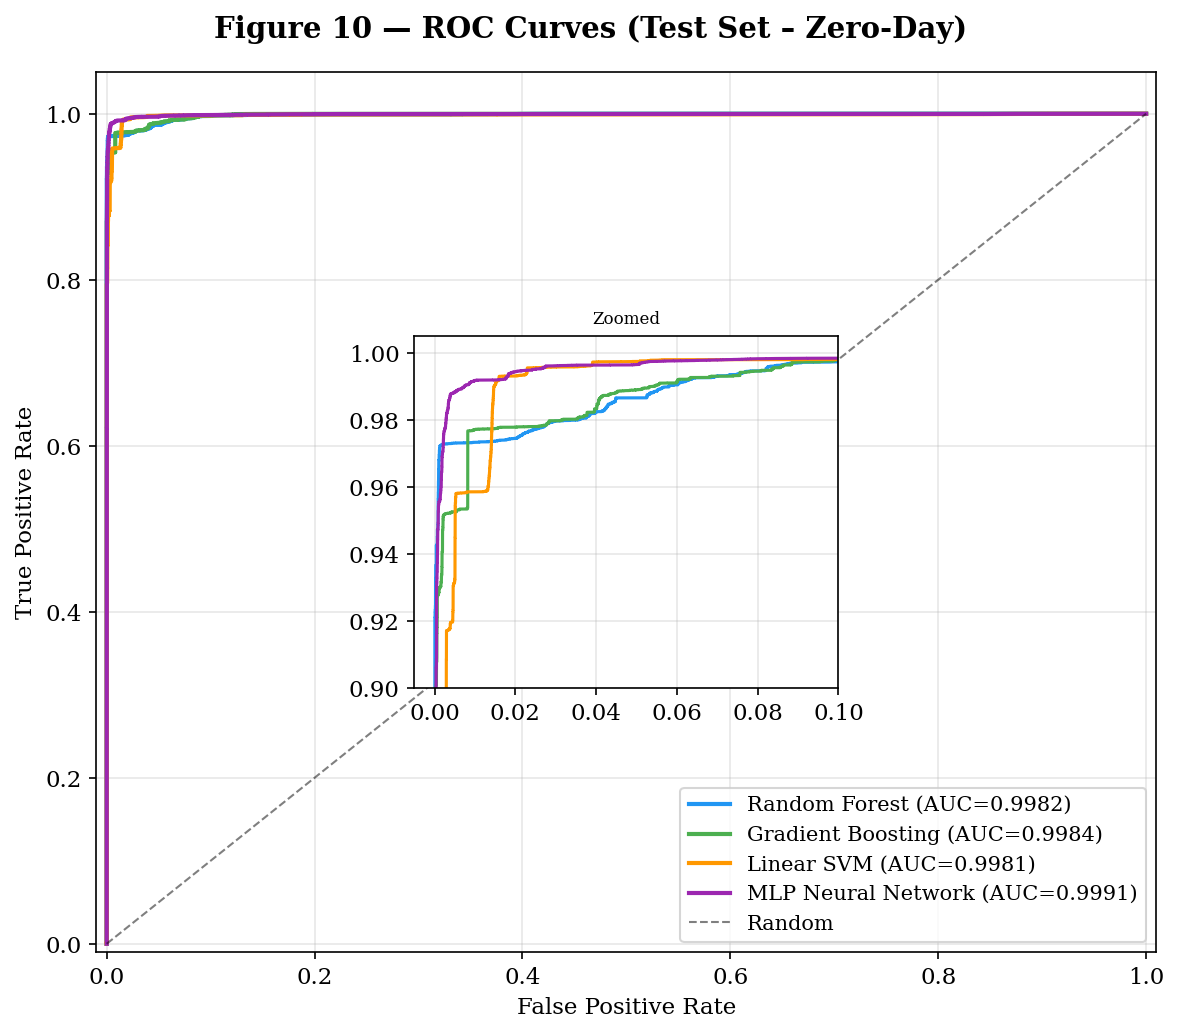

  ✅ Saved: /content/drive/MyDrive/Colab Notebooks/ddos_fig10_roc_curves.png


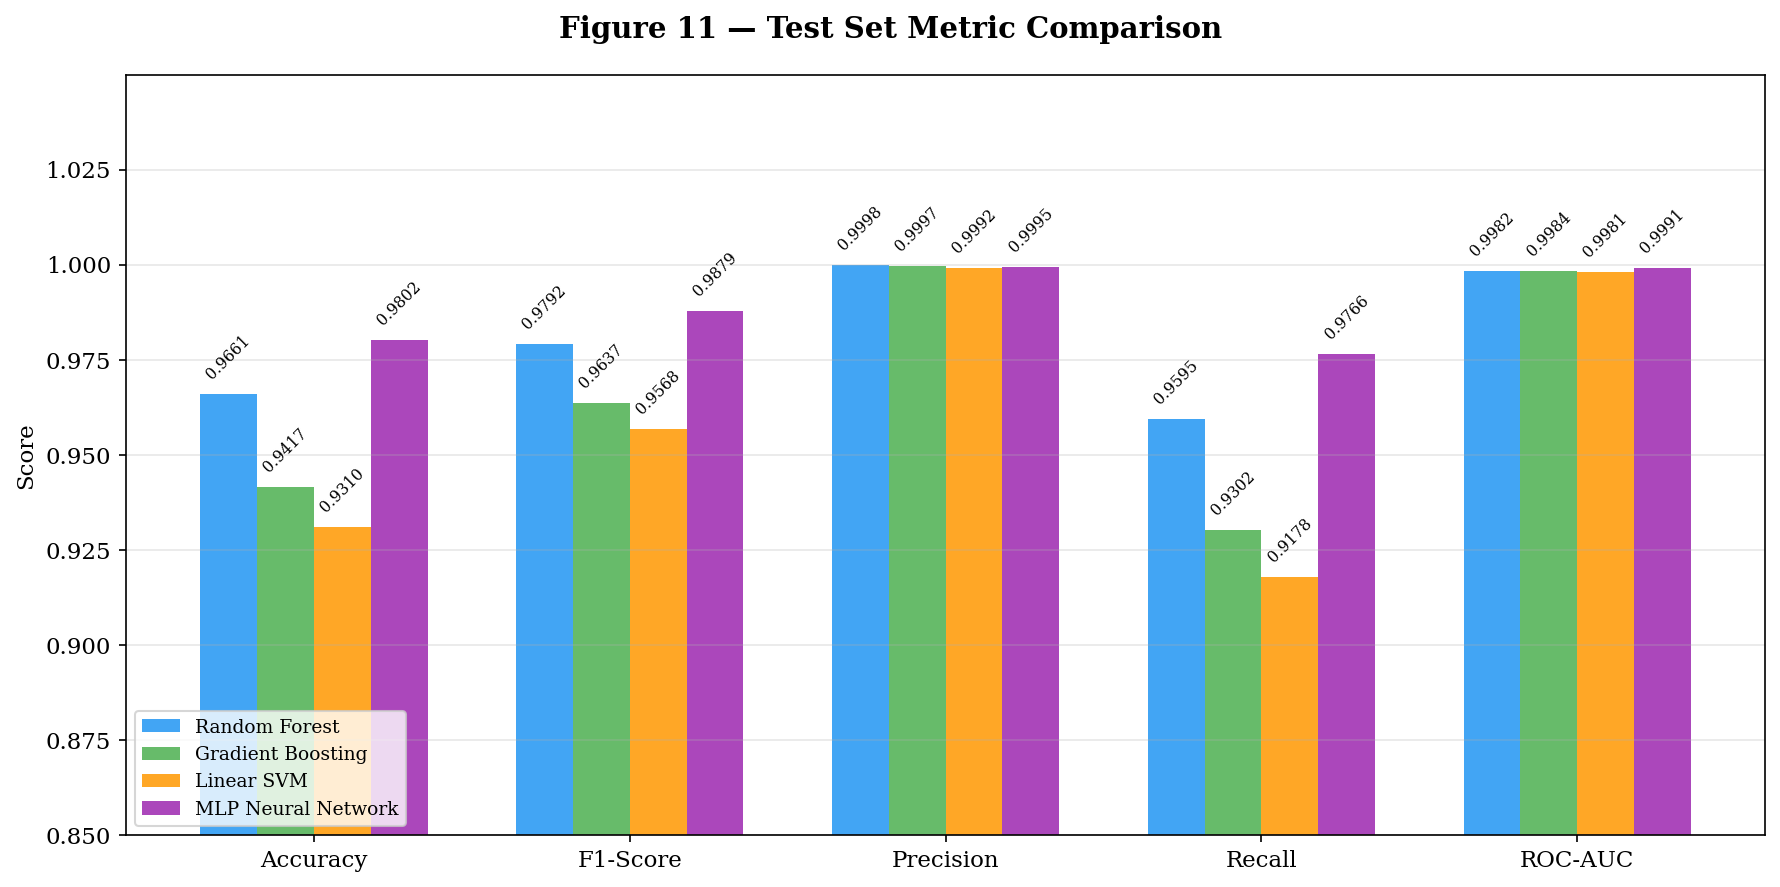

  ✅ Saved: /content/drive/MyDrive/Colab Notebooks/ddos_fig11_metric_comparison.png


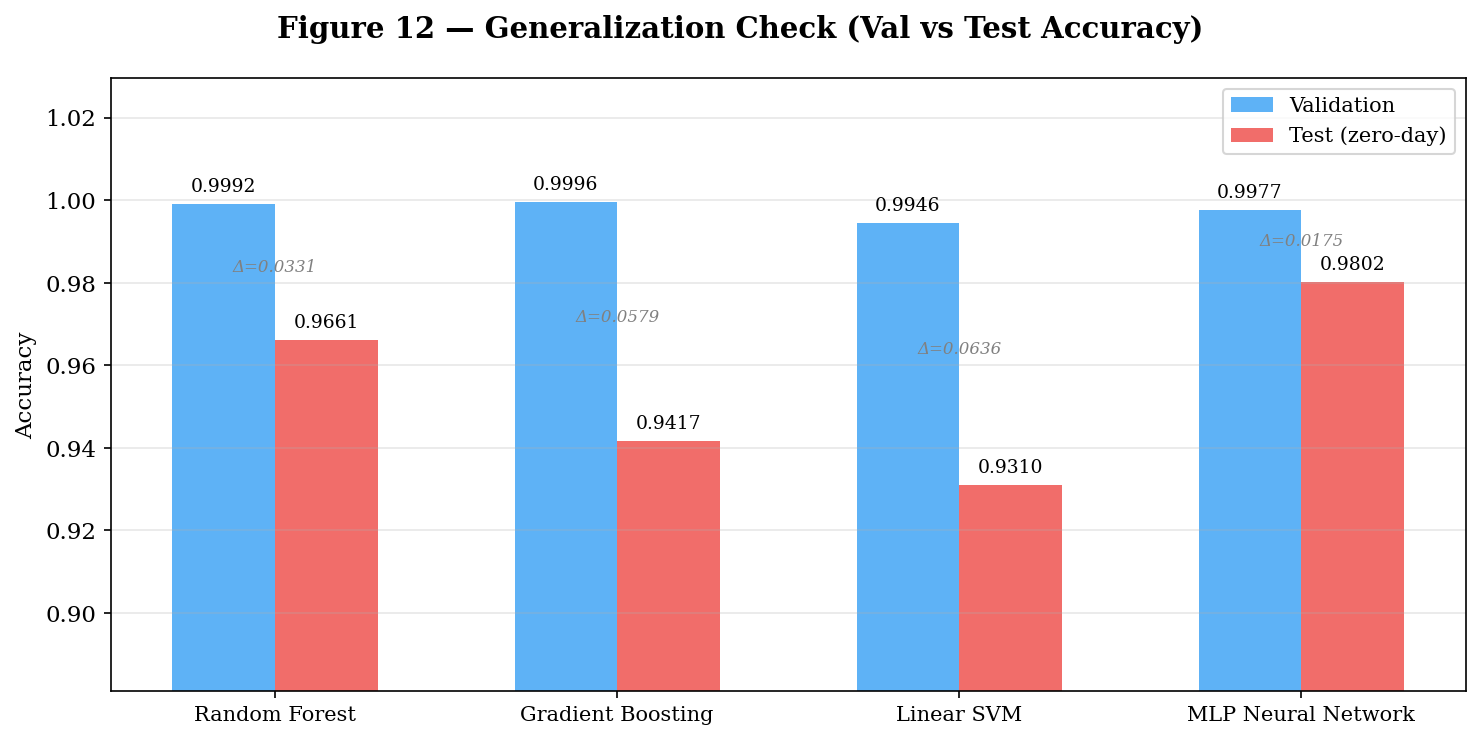

  ✅ Saved: /content/drive/MyDrive/Colab Notebooks/ddos_fig12_generalization.png


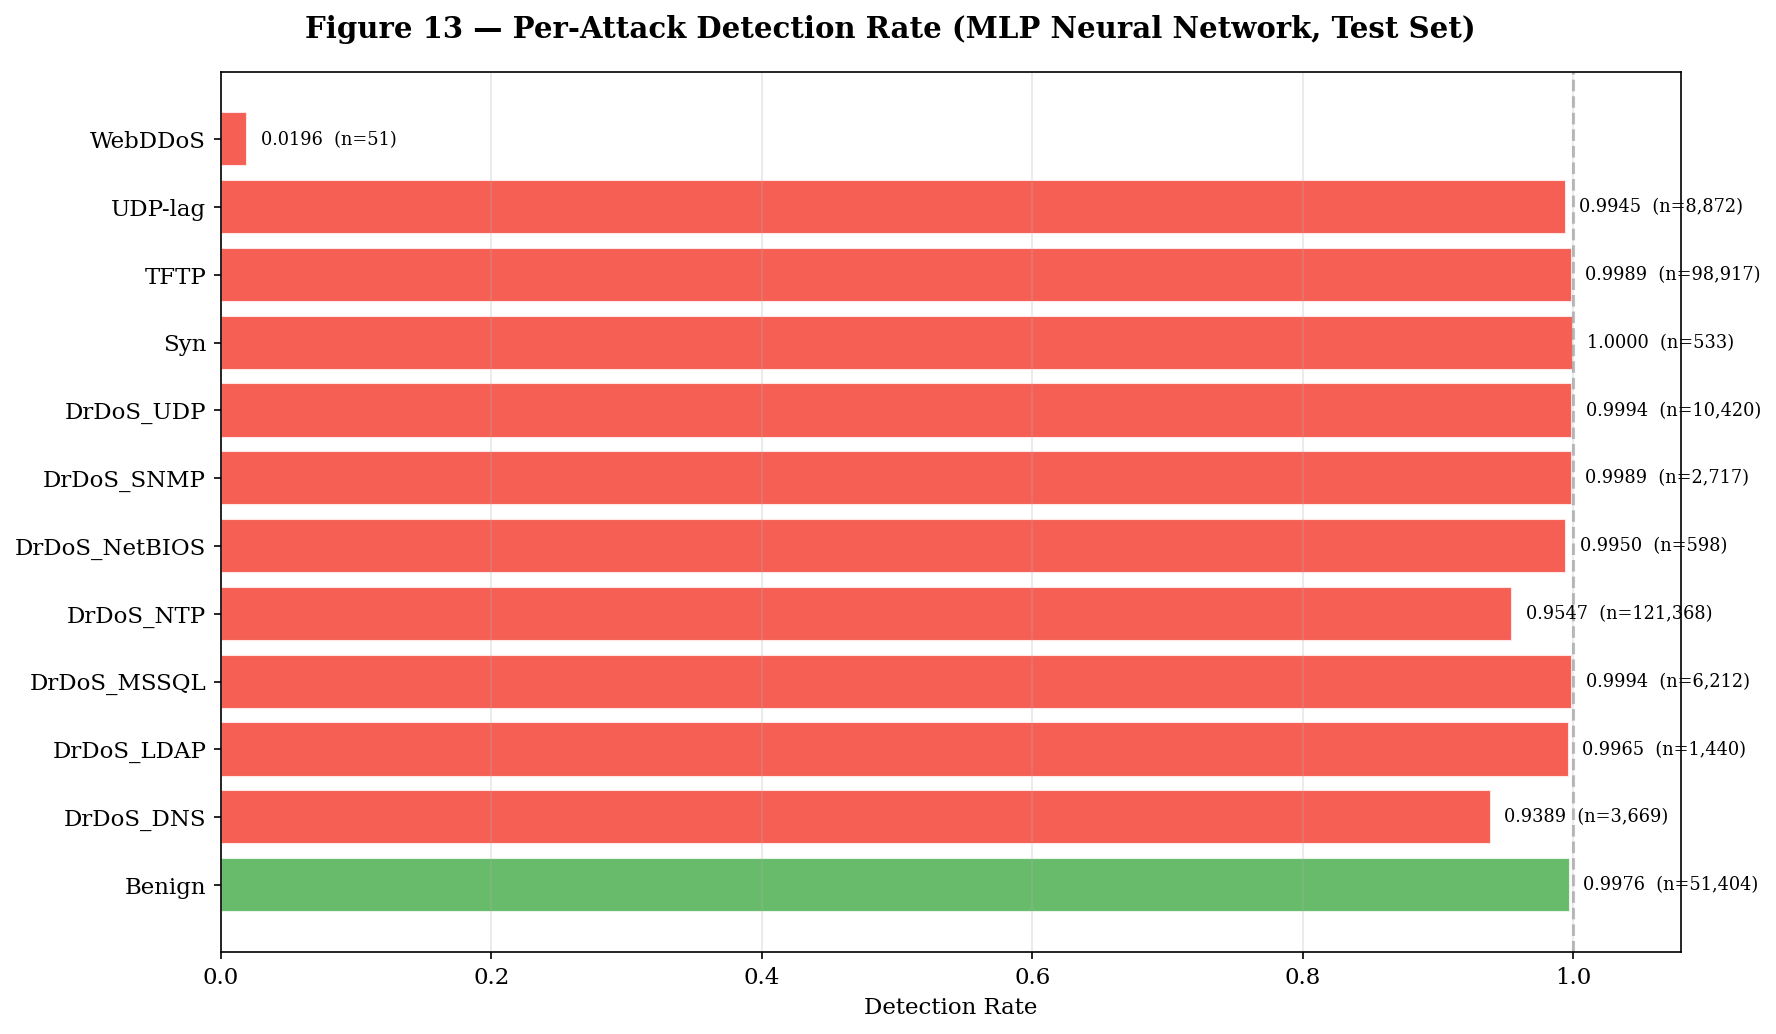

  ✅ Saved: /content/drive/MyDrive/Colab Notebooks/ddos_fig13_attack_detection.png


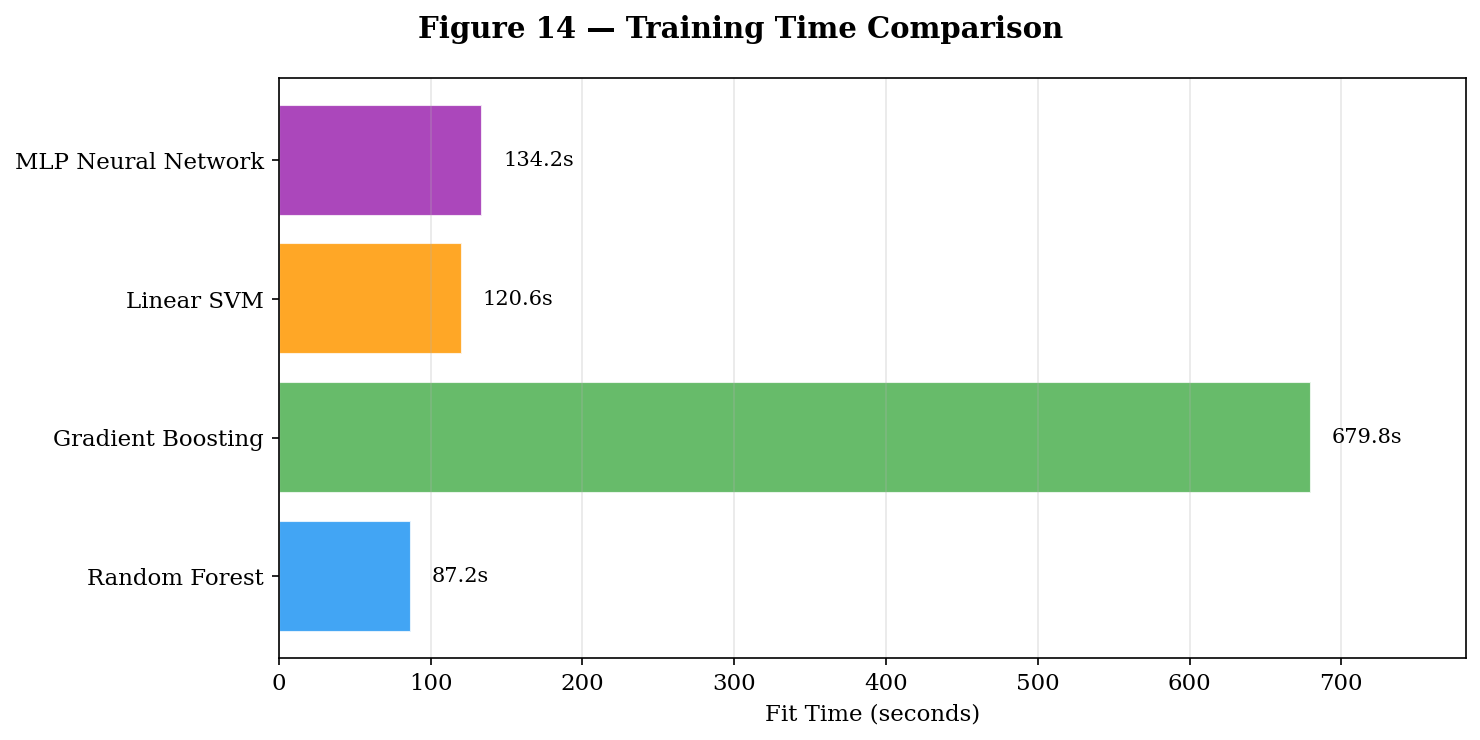

  ✅ Saved: /content/drive/MyDrive/Colab Notebooks/ddos_fig14_training_time.png

  EVALUATION FIGURES SUMMARY
  Figures saved to: /content/drive/MyDrive/Colab Notebooks
  • ddos_fig9_confusion_matrices.png
  • ddos_fig10_roc_curves.png
  • ddos_fig11_metric_comparison.png
  • ddos_fig12_generalization.png
  • ddos_fig13_attack_detection.png
  • ddos_fig14_training_time.png
  Best model: MLP Neural Network (Test F1=0.9879)
  Time: 12.3s
  ✅ Ready for Cell 7 — Feature Importance (XAI)


In [6]:
# ════════════════════════════════════════════════════════════════════
#  CELL 6 — EVALUATION FIGURES (Binary Classification)
# ════════════════════════════════════════════════════════════════════

import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
import os, time

t0 = time.time()
SAVE = '/content/drive/MyDrive/Colab Notebooks'
os.makedirs(SAVE, exist_ok=True)

plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

model_names = list(results.keys())
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# ────────────────────────────────────────────────────────────────────
#  FIGURE 9 — Confusion Matrices (Test set, 2×2 grid)
# ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Figure 9 — Confusion Matrices (Test Set – Zero-Day)',
             fontsize=15, fontweight='bold', y=1.02)

for idx, (name, ax) in enumerate(zip(model_names, axes.flat)):
    cm = results[name]['test']['cm']
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack'])
    disp.plot(ax=ax, cmap='Blues', values_format=',', colorbar=False)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            pct = cm[i, j] / total * 100
            ax.texts[i * 2 + j].set_text(f'{cm[i,j]:,}\n({pct:.2f}%)')

plt.tight_layout()
fname = os.path.join(SAVE, 'ddos_fig9_confusion_matrices.png')
plt.savefig(fname); plt.show(); print(f'  ✅ Saved: {fname}')

# ────────────────────────────────────────────────────────────────────
#  FIGURE 10 — ROC Curves (full + zoomed inset)
# ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
fig.suptitle('Figure 10 — ROC Curves (Test Set – Zero-Day)',
             fontsize=14, fontweight='bold')

auc_scores = []
for idx, name in enumerate(model_names):
    y_proba = results[name]['test']['y_proba']
    fpr, tpr, _ = roc_curve(y_test_bin, y_proba)
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    ax.plot(fpr, tpr, color=colors[idx], lw=2,
            label=f'{name} (AUC={roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.grid(True, alpha=0.3)

# Zoomed inset (top-left corner) if AUCs are high
min_auc = min(auc_scores)
if min_auc > 0.90:
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    ax_ins = inset_axes(ax, width="40%", height="40%", loc='center')
    for idx, name in enumerate(model_names):
        y_proba = results[name]['test']['y_proba']
        fpr, tpr, _ = roc_curve(y_test_bin, y_proba)
        ax_ins.plot(fpr, tpr, color=colors[idx], lw=1.5)
    ax_ins.set_xlim([-0.005, 0.10])
    ax_ins.set_ylim([0.90, 1.005])
    ax_ins.set_title('Zoomed', fontsize=8)
    ax_ins.grid(True, alpha=0.3)

plt.tight_layout()
fname = os.path.join(SAVE, 'ddos_fig10_roc_curves.png')
plt.savefig(fname); plt.show(); print(f'  ✅ Saved: {fname}')

# ────────────────────────────────────────────────────────────────────
#  FIGURE 11 — Metric Comparison Bar Chart (adaptive y-axis)
# ────────────────────────────────────────────────────────────────────
metrics_list = ['acc', 'f1', 'prec', 'rec', 'auc']
metrics_labels = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Figure 11 — Test Set Metric Comparison',
             fontsize=14, fontweight='bold')

x = np.arange(len(metrics_list))
width = 0.18

all_vals = []
for idx, name in enumerate(model_names):
    vals = [results[name]['test'][m] for m in metrics_list]
    all_vals.extend(vals)
    bars = ax.bar(x + idx * width, vals, width, label=name,
                  color=colors[idx], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_labels)
# Adaptive y-axis: floor to nearest 0.05 below min, cap at 1.02
y_min = max(0, (min(all_vals) // 0.05) * 0.05 - 0.05)
ax.set_ylim([y_min, min(max(all_vals) + 0.05, 1.05)])
ax.set_ylabel('Score')
ax.legend(loc='lower left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fname = os.path.join(SAVE, 'ddos_fig11_metric_comparison.png')
plt.savefig(fname); plt.show(); print(f'  ✅ Saved: {fname}')

# ────────────────────────────────────────────────────────────────────
#  FIGURE 12 — Generalization: Validation vs Test Accuracy (adaptive)
# ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Figure 12 — Generalization Check (Val vs Test Accuracy)',
             fontsize=14, fontweight='bold')

x = np.arange(len(model_names))
width = 0.3

val_accs  = [results[n]['val']['acc'] for n in model_names]
test_accs = [results[n]['test']['acc'] for n in model_names]
all_accs  = val_accs + test_accs

bars1 = ax.bar(x - width/2, val_accs, width, label='Validation',
               color='#42A5F5', alpha=0.85)
bars2 = ax.bar(x + width/2, test_accs, width, label='Test (zero-day)',
               color='#EF5350', alpha=0.85)

for bar, v in zip(list(bars1) + list(bars2), all_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
y_min_gen = max(0, min(all_accs) - 0.05)
ax.set_ylim([y_min_gen, min(max(all_accs) + 0.03, 1.05)])
ax.set_ylabel('Accuracy')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add delta annotations
for i, n in enumerate(model_names):
    delta = results[n]['gap']
    mid_y = (val_accs[i] + test_accs[i]) / 2
    ax.annotate(f'Δ={delta:.4f}', xy=(i, mid_y), fontsize=8,
                ha='center', color='gray', fontstyle='italic')

plt.tight_layout()
fname = os.path.join(SAVE, 'ddos_fig12_generalization.png')
plt.savefig(fname); plt.show(); print(f'  ✅ Saved: {fname}')

# ────────────────────────────────────────────────────────────────────
#  FIGURE 13 — Per-Attack-Type Detection Rate (Best model, adaptive)
# ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle(f'Figure 13 — Per-Attack Detection Rate ({best_name}, Test Set)',
             fontsize=14, fontweight='bold')

test_labels = df_all.loc[test_mask, 'Label'].values
y_pred_best = results[best_name]['test']['y_pred']

attack_types = sorted(set(test_labels))
detect_rates = []
counts = []
for label in attack_types:
    mask_l = (test_labels == label)
    n = mask_l.sum()
    pred = y_pred_best[mask_l]
    if label == 'Benign':
        rate = (pred == 0).sum() / n
    else:
        rate = (pred == 1).sum() / n
    detect_rates.append(rate)
    counts.append(n)

bar_colors = ['#4CAF50' if label == 'Benign' else '#F44336' for label in attack_types]
bars = ax.barh(attack_types, detect_rates, color=bar_colors, alpha=0.85, edgecolor='white')

for bar, rate, cnt in zip(bars, detect_rates, counts):
    ax.text(max(rate + 0.01, 0.02), bar.get_y() + bar.get_height()/2,
            f'{rate:.4f}  (n={cnt:,})', va='center', fontsize=8.5)

# Adaptive x-axis
x_min = max(0, min(detect_rates) - 0.10)
ax.set_xlim([x_min, min(max(detect_rates) + 0.08, 1.08)])
ax.set_xlabel('Detection Rate')
ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fname = os.path.join(SAVE, 'ddos_fig13_attack_detection.png')
plt.savefig(fname); plt.show(); print(f'  ✅ Saved: {fname}')

# ────────────────────────────────────────────────────────────────────
#  FIGURE 14 — Training Time Comparison
# ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Figure 14 — Training Time Comparison',
             fontsize=14, fontweight='bold')

times = [results[n]['fit_time'] for n in model_names]
bars = ax.barh(model_names, times, color=colors, alpha=0.85, edgecolor='white')

for bar, t in zip(bars, times):
    ax.text(bar.get_width() + max(times)*0.02, bar.get_y() + bar.get_height()/2,
            f'{t:.1f}s', va='center', fontsize=10)

ax.set_xlabel('Fit Time (seconds)')
ax.set_xlim([0, max(times) * 1.15])
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fname = os.path.join(SAVE, 'ddos_fig14_training_time.png')
plt.savefig(fname); plt.show(); print(f'  ✅ Saved: {fname}')

# ────────────────────────────────────────────────────────────────────
#  SUMMARY
# ────────────────────────────────────────────────────────────────────
elapsed = time.time() - t0
print(f'\n{"="*70}')
print(f'  EVALUATION FIGURES SUMMARY')
print(f'{"="*70}')
print(f'  Figures saved to: {SAVE}')
figs = ['ddos_fig9_confusion_matrices.png', 'ddos_fig10_roc_curves.png',
        'ddos_fig11_metric_comparison.png', 'ddos_fig12_generalization.png',
        'ddos_fig13_attack_detection.png', 'ddos_fig14_training_time.png']
for f in figs:
    print(f'  • {f}')
print(f'  Best model: {best_name} (Test F1={best_r["test"]["f1"]:.4f})')
print(f'  Time: {elapsed:.1f}s')
print(f'{"="*70}')
print(f'  ✅ Ready for Cell 7 — Feature Importance (XAI)')
print(f'{"="*70}')


  CELL 7 — FEATURE IMPORTANCE (XAI)
  Best model : MLP Neural Network
  Test set   : 306,201 × 58
  Features   : 58

[A] Permutation Importance — MLP Neural Network (5 repeats, F1)...
  Time: 1645.5s

  Top 15 features — MLP Neural Network (permutation F1 drop ± std):
  Rank   Feature                              Mean Drop      ± Std
  ---------------------------------------------------------------
  1      Fwd Act Data Packets                  0.036859 ± 0.000115  
  2      ACK Flag Count                        0.016256 ± 0.000087  
  3      Fwd Packets Length Total              0.015391 ± 0.000142  
  4      Init Bwd Win Bytes                    0.008583 ± 0.000068  
  5      Bwd Packet Length Min                 0.007615 ± 0.000061  

[B] Permutation Importance — Random Forest (5 repeats, F1)...
  Time: 3536.4s

  Top 15 features — Random Forest (permutation F1 drop ± std):
  Rank   Feature                              Mean Drop      ± Std
  -----------------------------------------

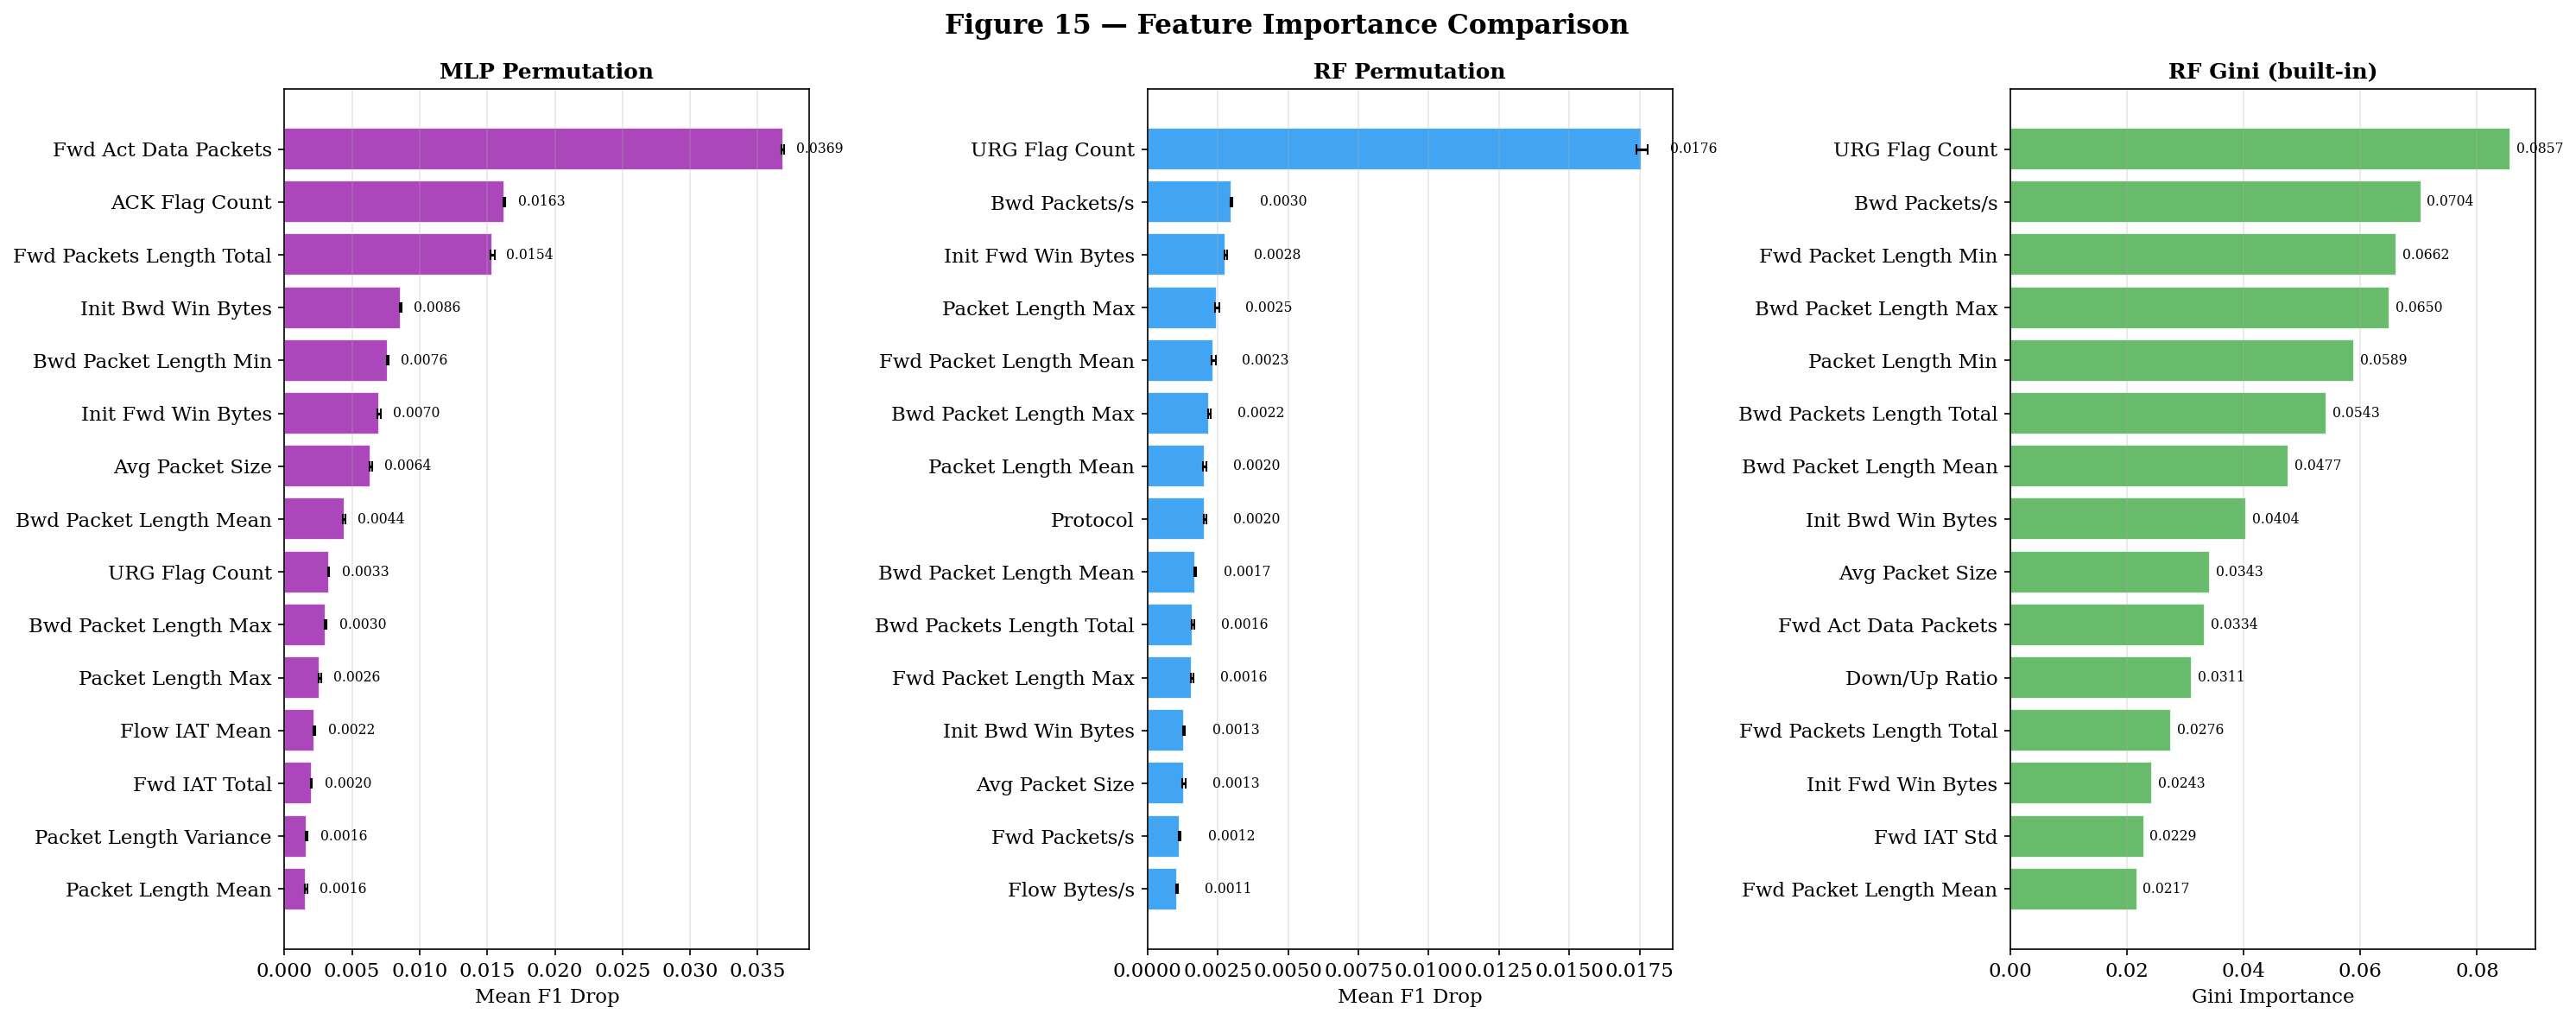

  ✅ Saved: /content/drive/MyDrive/Colab Notebooks/ddos_fig15_feature_importance.png


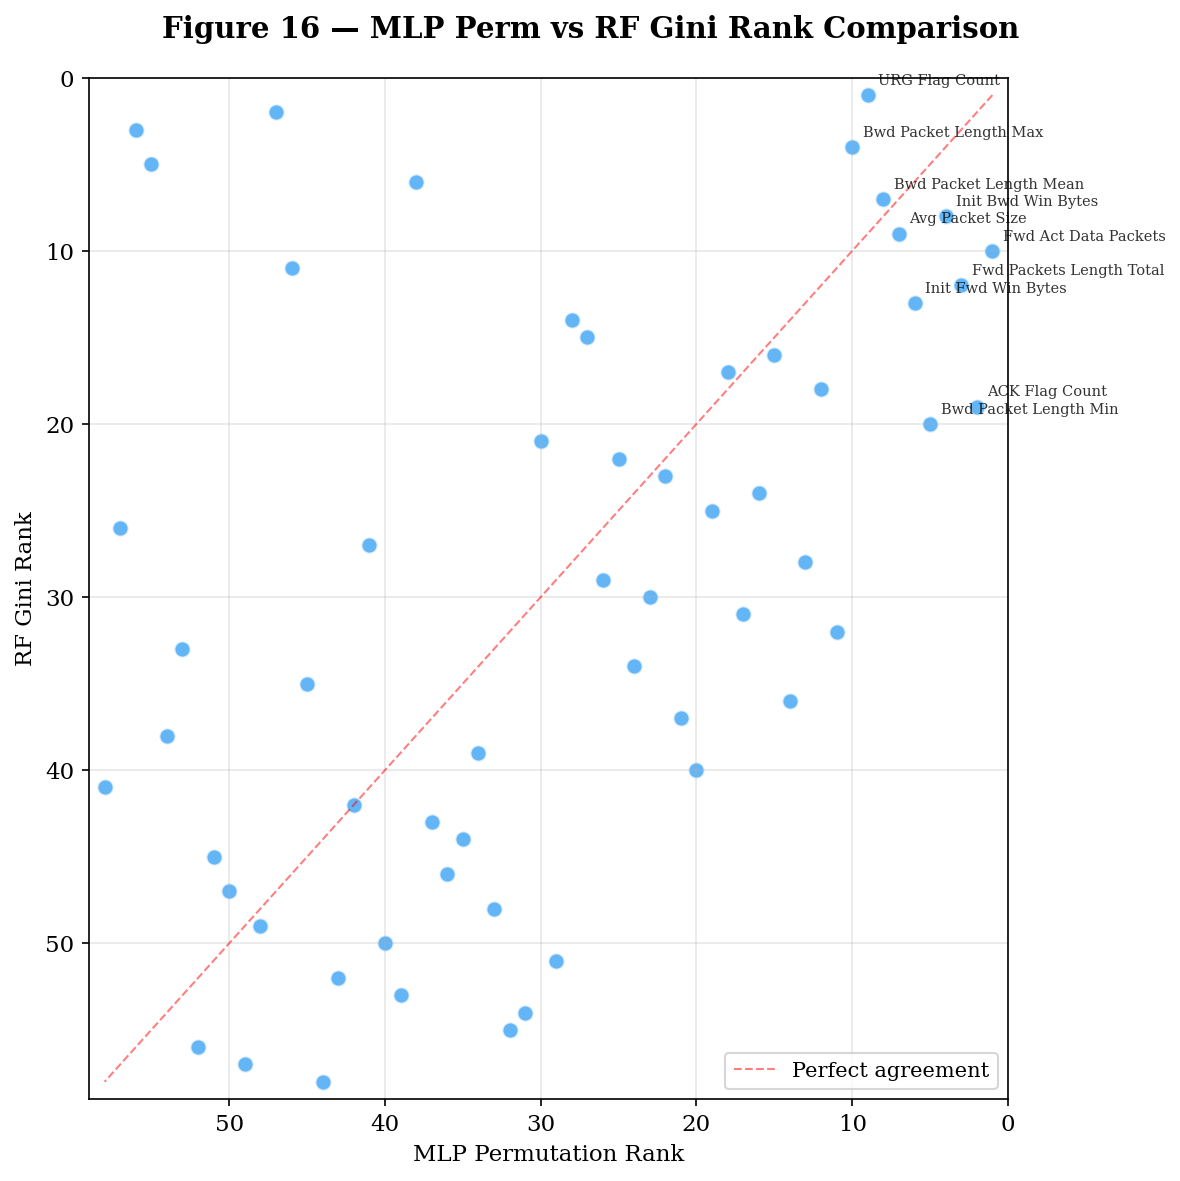

  ✅ Saved: /content/drive/MyDrive/Colab Notebooks/ddos_fig16_rank_comparison.png

  XAI SUMMARY
  Best model (MLP)    : Top perm feature = Fwd Act Data Packets (0.036859)
  Random Forest       : Top perm feature = URG Flag Count (0.017577)
  Random Forest       : Top Gini feature = URG Flag Count (0.085715)
  Agreement (all 3)   : 6/15
  Common features     : Bwd Packet Length Max, Bwd Packet Length Mean, URG Flag Count, Avg Packet Size, Init Fwd Win Bytes, Init Bwd Win Bytes
  Figures             : ddos_fig15_feature_importance.png
                        ddos_fig16_rank_comparison.png
  Time                : 5188.6s
  ✅ Ready for Cell 8 — t-SNE Visualisation


In [7]:
# ════════════════════════════════════════════════════════════════════
#  CELL 7 — FEATURE IMPORTANCE (XAI)
#  Best model: MLP Neural Network (no built-in Gini importance)
#  → Permutation Importance only
# ════════════════════════════════════════════════════════════════════

import numpy as np, matplotlib.pyplot as plt, time, os
from sklearn.inspection import permutation_importance
import warnings; warnings.filterwarnings('ignore')

t0 = time.time()
SAVE = '/content/drive/MyDrive/Colab Notebooks'
os.makedirs(SAVE, exist_ok=True)

print('='*70)
print('  CELL 7 — FEATURE IMPORTANCE (XAI)')
print(f'  Best model : {best_name}')
print(f'  Test set   : {X_test_sc.shape[0]:,} × {X_test_sc.shape[1]}')
print(f'  Features   : {len(feat_names)}')
print('='*70)

# ────────────────────────────────────────────────────────────────────
#  [A] PERMUTATION IMPORTANCE — Best model (MLP)
# ────────────────────────────────────────────────────────────────────
print(f'\n[A] Permutation Importance — {best_name} (5 repeats, F1)...')
t_perm = time.time()

perm_best = permutation_importance(
    best_model, X_test_sc, y_test_bin,
    n_repeats=15, scoring='f1', random_state=42, n_jobs=-1
)

perm_time_best = time.time() - t_perm
print(f'  Time: {perm_time_best:.1f}s')

perm_order_best = np.argsort(perm_best.importances_mean)[::-1]

print(f'\n  Top 15 features — {best_name} (permutation F1 drop ± std):')
print(f'  {"Rank":<6} {"Feature":<35} {"Mean Drop":>10} {"± Std":>10}')
print(f'  {"-"*63}')
for rank, idx in enumerate(perm_order_best[:5], 1):
    print(f'  {rank:<6} {feat_names[idx]:<35} '
          f'{perm_best.importances_mean[idx]:>10.6f} '
          f'± {perm_best.importances_std[idx]:<10.6f}')

# ────────────────────────────────────────────────────────────────────
#  [B] PERMUTATION IMPORTANCE — Random Forest (for comparison)
# ────────────────────────────────────────────────────────────────────
rf_model = results['Random Forest']['model']

print(f'\n[B] Permutation Importance — Random Forest (5 repeats, F1)...')
t_perm2 = time.time()

perm_rf = permutation_importance(
    rf_model, X_test_sc, y_test_bin,
    n_repeats=15, scoring='f1', random_state=42, n_jobs=-1
)

perm_time_rf = time.time() - t_perm2
print(f'  Time: {perm_time_rf:.1f}s')

perm_order_rf = np.argsort(perm_rf.importances_mean)[::-1]

print(f'\n  Top 15 features — Random Forest (permutation F1 drop ± std):')
print(f'  {"Rank":<6} {"Feature":<35} {"Mean Drop":>10} {"± Std":>10}')
print(f'  {"-"*63}')
for rank, idx in enumerate(perm_order_rf[:5], 1):
    print(f'  {rank:<6} {feat_names[idx]:<35} '
          f'{perm_rf.importances_mean[idx]:>10.6f} '
          f'± {perm_rf.importances_std[idx]:<10.6f}')

# ────────────────────────────────────────────────────────────────────
#  [C] GINI IMPORTANCE — Random Forest (built-in, instant)
# ────────────────────────────────────────────────────────────────────
print(f'\n[C] Built-in Gini Importance — Random Forest')
gini_imp = rf_model.feature_importances_
gini_order = np.argsort(gini_imp)[::-1]

print(f'\n  Top 15 features (Gini importance):')
print(f'  {"Rank":<6} {"Feature":<35} {"Importance":>12}')
print(f'  {"-"*55}')
for rank, idx in enumerate(gini_order[:15], 1):
    print(f'  {rank:<6} {feat_names[idx]:<35} {gini_imp[idx]:>12.6f}')

# ────────────────────────────────────────────────────────────────────
#  [D] AGREEMENT ANALYSIS
# ────────────────────────────────────────────────────────────────────
top15_mlp  = set(perm_order_best[:15])
top15_rf   = set(perm_order_rf[:15])
top15_gini = set(gini_order[:15])

common_mlp_rf   = top15_mlp & top15_rf
common_mlp_gini = top15_mlp & top15_gini
common_all      = top15_mlp & top15_rf & top15_gini

print(f'\n[D] Agreement Analysis (Top 15):')
print(f'  MLP Perm ∩ RF Perm  : {len(common_mlp_rf)}/15')
print(f'  MLP Perm ∩ RF Gini  : {len(common_mlp_gini)}/15')
print(f'  All three methods   : {len(common_all)}/15')
print(f'  Common (all 3)      : {", ".join(feat_names[i] for i in sorted(common_all))}')

# ────────────────────────────────────────────────────────────────────
#  FIGURE 15 — Feature Importance: MLP Perm vs RF Perm vs RF Gini
# ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Figure 15 — Feature Importance Comparison',
             fontsize=15, fontweight='bold')

# Left: MLP Permutation
top15_idx = perm_order_best[:15][::-1]
ax1.barh([feat_names[i] for i in top15_idx],
         perm_best.importances_mean[top15_idx],
         xerr=perm_best.importances_std[top15_idx],
         color='#9C27B0', alpha=0.85, edgecolor='white', capsize=3)
for i, idx in enumerate(top15_idx):
    ax1.text(perm_best.importances_mean[idx] + 0.001, i,
             f'{perm_best.importances_mean[idx]:.4f}', va='center', fontsize=7.5)
ax1.set_xlabel('Mean F1 Drop')
ax1.set_title(f'MLP Permutation', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Center: RF Permutation
top15_idx_rf = perm_order_rf[:15][::-1]
ax2.barh([feat_names[i] for i in top15_idx_rf],
         perm_rf.importances_mean[top15_idx_rf],
         xerr=perm_rf.importances_std[top15_idx_rf],
         color='#2196F3', alpha=0.85, edgecolor='white', capsize=3)
for i, idx in enumerate(top15_idx_rf):
    ax2.text(perm_rf.importances_mean[idx] + 0.001, i,
             f'{perm_rf.importances_mean[idx]:.4f}', va='center', fontsize=7.5)
ax2.set_xlabel('Mean F1 Drop')
ax2.set_title('RF Permutation', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Right: RF Gini
top15_idx_g = gini_order[:15][::-1]
ax3.barh([feat_names[i] for i in top15_idx_g],
         gini_imp[top15_idx_g],
         color='#4CAF50', alpha=0.85, edgecolor='white')
for i, idx in enumerate(top15_idx_g):
    ax3.text(gini_imp[idx] + 0.001, i,
             f'{gini_imp[idx]:.4f}', va='center', fontsize=7.5)
ax3.set_xlabel('Gini Importance')
ax3.set_title('RF Gini (built-in)', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
fname = os.path.join(SAVE, 'ddos_fig15_feature_importance.png')
plt.savefig(fname); plt.show(); print(f'  ✅ Saved: {fname}')

# ────────────────────────────────────────────────────────────────────
#  FIGURE 16 — Rank Comparison: MLP Perm vs RF Gini
# ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
fig.suptitle('Figure 16 — MLP Perm vs RF Gini Rank Comparison',
             fontsize=14, fontweight='bold')

mlp_ranks = np.zeros(len(feat_names))
gini_ranks = np.zeros(len(feat_names))
mlp_ranks[perm_order_best] = np.arange(1, len(feat_names) + 1)
gini_ranks[gini_order] = np.arange(1, len(feat_names) + 1)

ax.scatter(mlp_ranks, gini_ranks, c='#2196F3', alpha=0.7, s=60, edgecolors='white')

for idx in perm_order_best[:10]:
    ax.annotate(feat_names[idx], (mlp_ranks[idx], gini_ranks[idx]),
                fontsize=7, alpha=0.8,
                xytext=(5, 5), textcoords='offset points')

ax.plot([1, len(feat_names)], [1, len(feat_names)],
        'r--', lw=1, alpha=0.5, label='Perfect agreement')
ax.set_xlabel('MLP Permutation Rank')
ax.set_ylabel('RF Gini Rank')
ax.legend(fontsize=10)
ax.set_xlim([0, len(feat_names) + 1])
ax.set_ylim([0, len(feat_names) + 1])
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
ax.invert_xaxis()

plt.tight_layout()
fname = os.path.join(SAVE, 'ddos_fig16_rank_comparison.png')
plt.savefig(fname); plt.show(); print(f'  ✅ Saved: {fname}')

# ────────────────────────────────────────────────────────────────────
#  SUMMARY
# ────────────────────────────────────────────────────────────────────
elapsed = time.time() - t0
print(f'\n{"="*70}')
print(f'  XAI SUMMARY')
print(f'{"="*70}')
print(f'  Best model (MLP)    : Top perm feature = {feat_names[perm_order_best[0]]} '
      f'({perm_best.importances_mean[perm_order_best[0]]:.6f})')
print(f'  Random Forest       : Top perm feature = {feat_names[perm_order_rf[0]]} '
      f'({perm_rf.importances_mean[perm_order_rf[0]]:.6f})')
print(f'  Random Forest       : Top Gini feature = {feat_names[gini_order[0]]} '
      f'({gini_imp[gini_order[0]]:.6f})')
print(f'  Agreement (all 3)   : {len(common_all)}/15')
print(f'  Common features     : {", ".join(feat_names[i] for i in sorted(common_all))}')
print(f'  Figures             : ddos_fig15_feature_importance.png')
print(f'                        ddos_fig16_rank_comparison.png')
print(f'  Time                : {elapsed:.1f}s')
print(f'{"="*70}')
print(f'  ✅ Ready for Cell 8 — t-SNE Visualisation')
print(f'{"="*70}')


  CELL 8 — t-SNE LATENT SPACE VISUALISATION
  Samples selected : 6,000 (Benign: 3,000 | Attack: 3,000)
  Features         : 58

[2] PCA dimensionality reduction ...
  PCA: 58 → 15 dimensions (99.9% variance)

[3] t-SNE projection (perplexity=30, 1000 iter) ...
  t-SNE time       : 61.1s
  KL divergence    : 0.3234


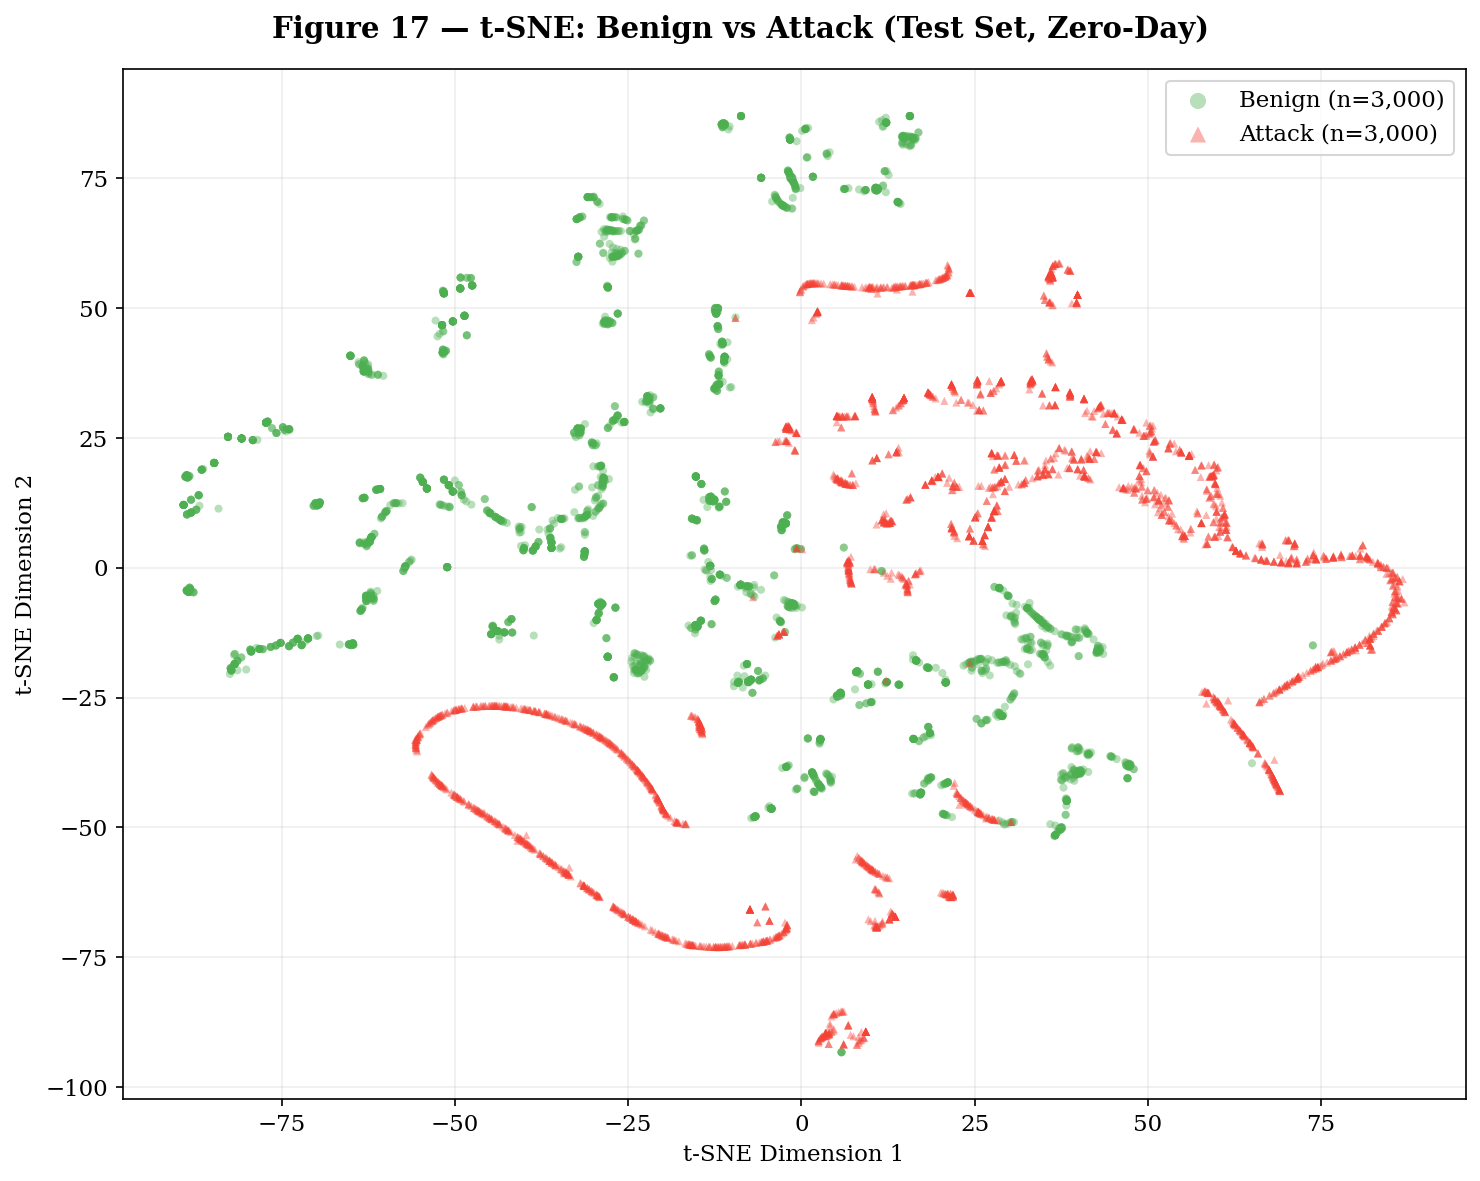

  ✅ Saved: /content/drive/MyDrive/Colab Notebooks/ddos_fig17_tsne_binary.png


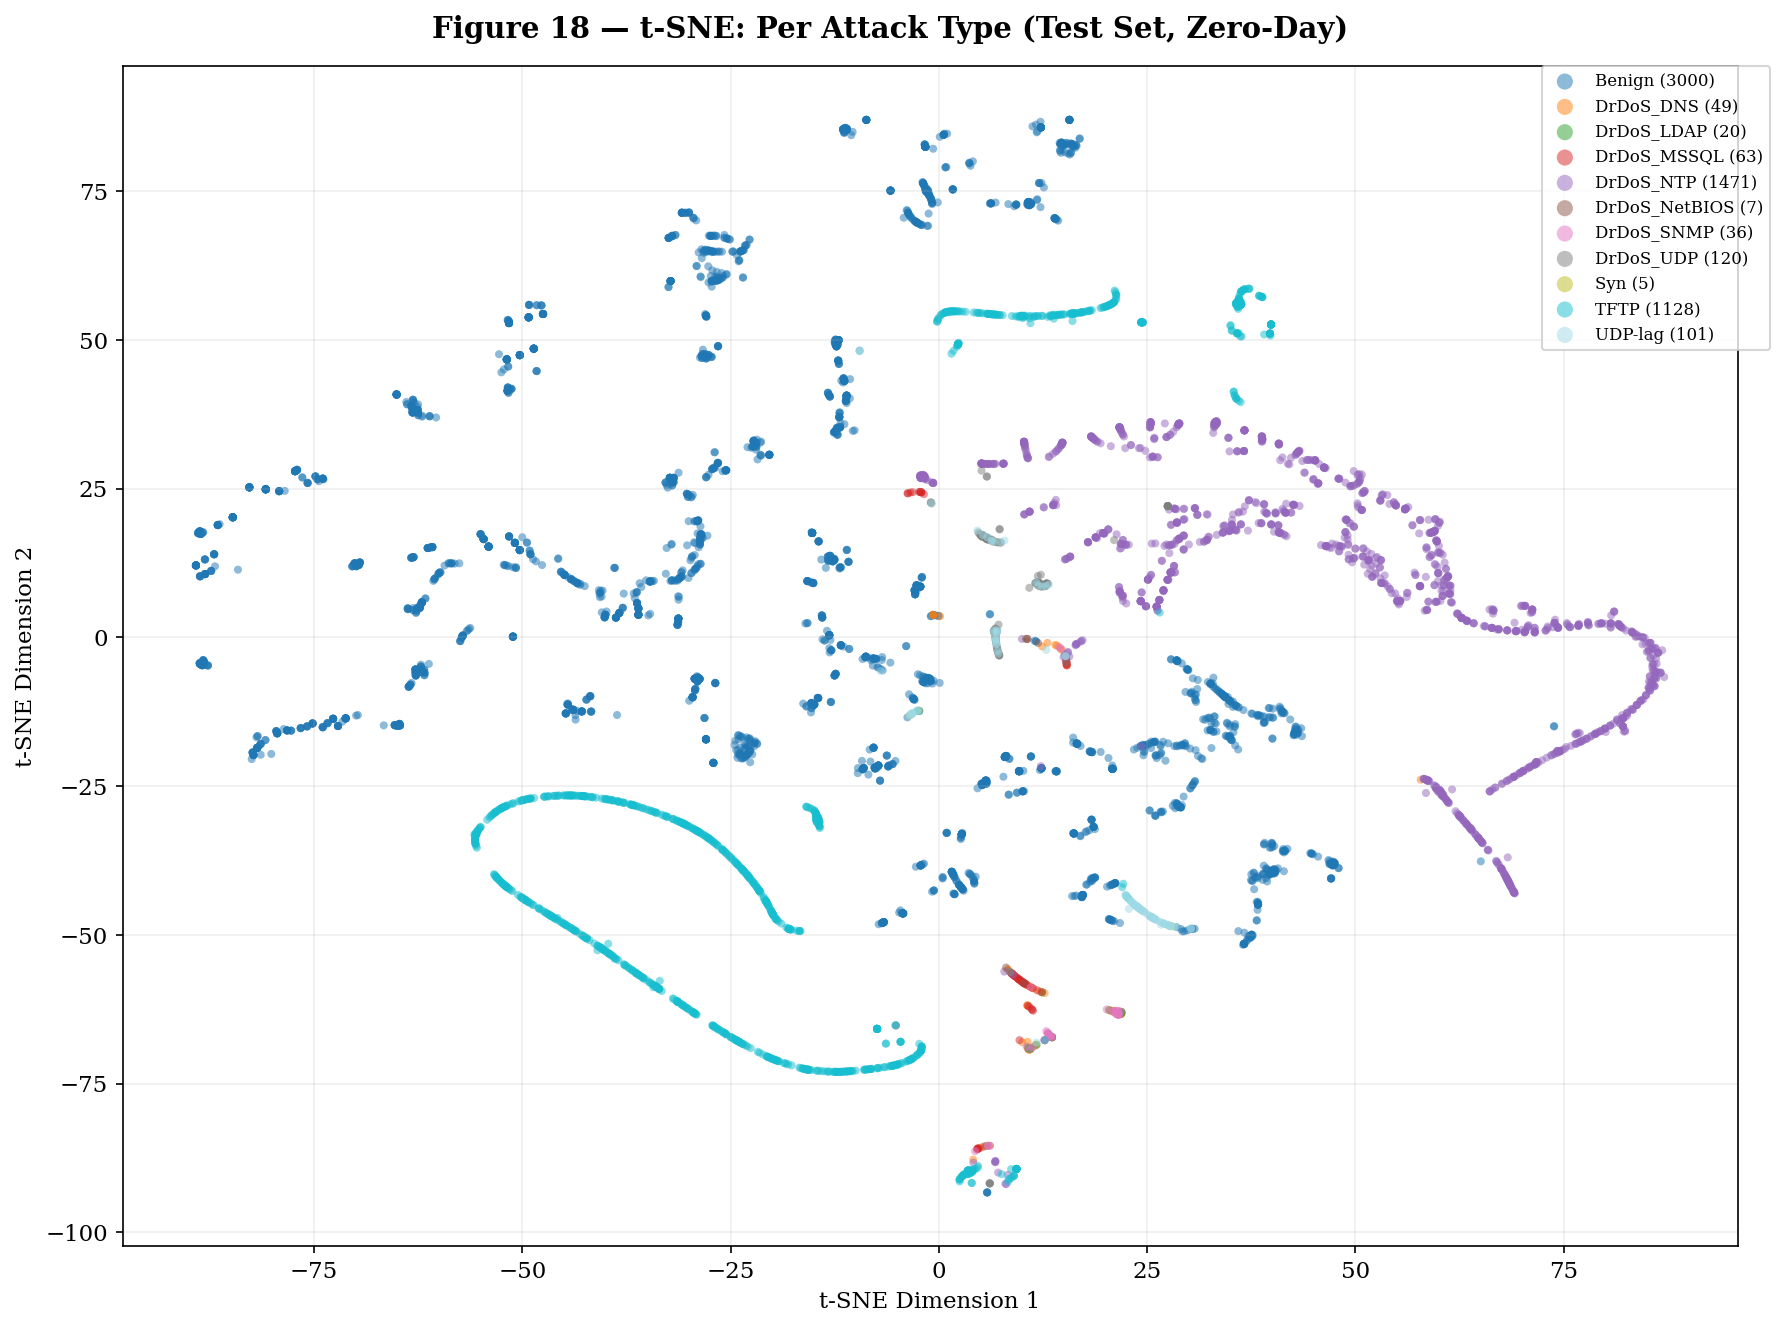

  ✅ Saved: /content/drive/MyDrive/Colab Notebooks/ddos_fig18_tsne_attack_types.png


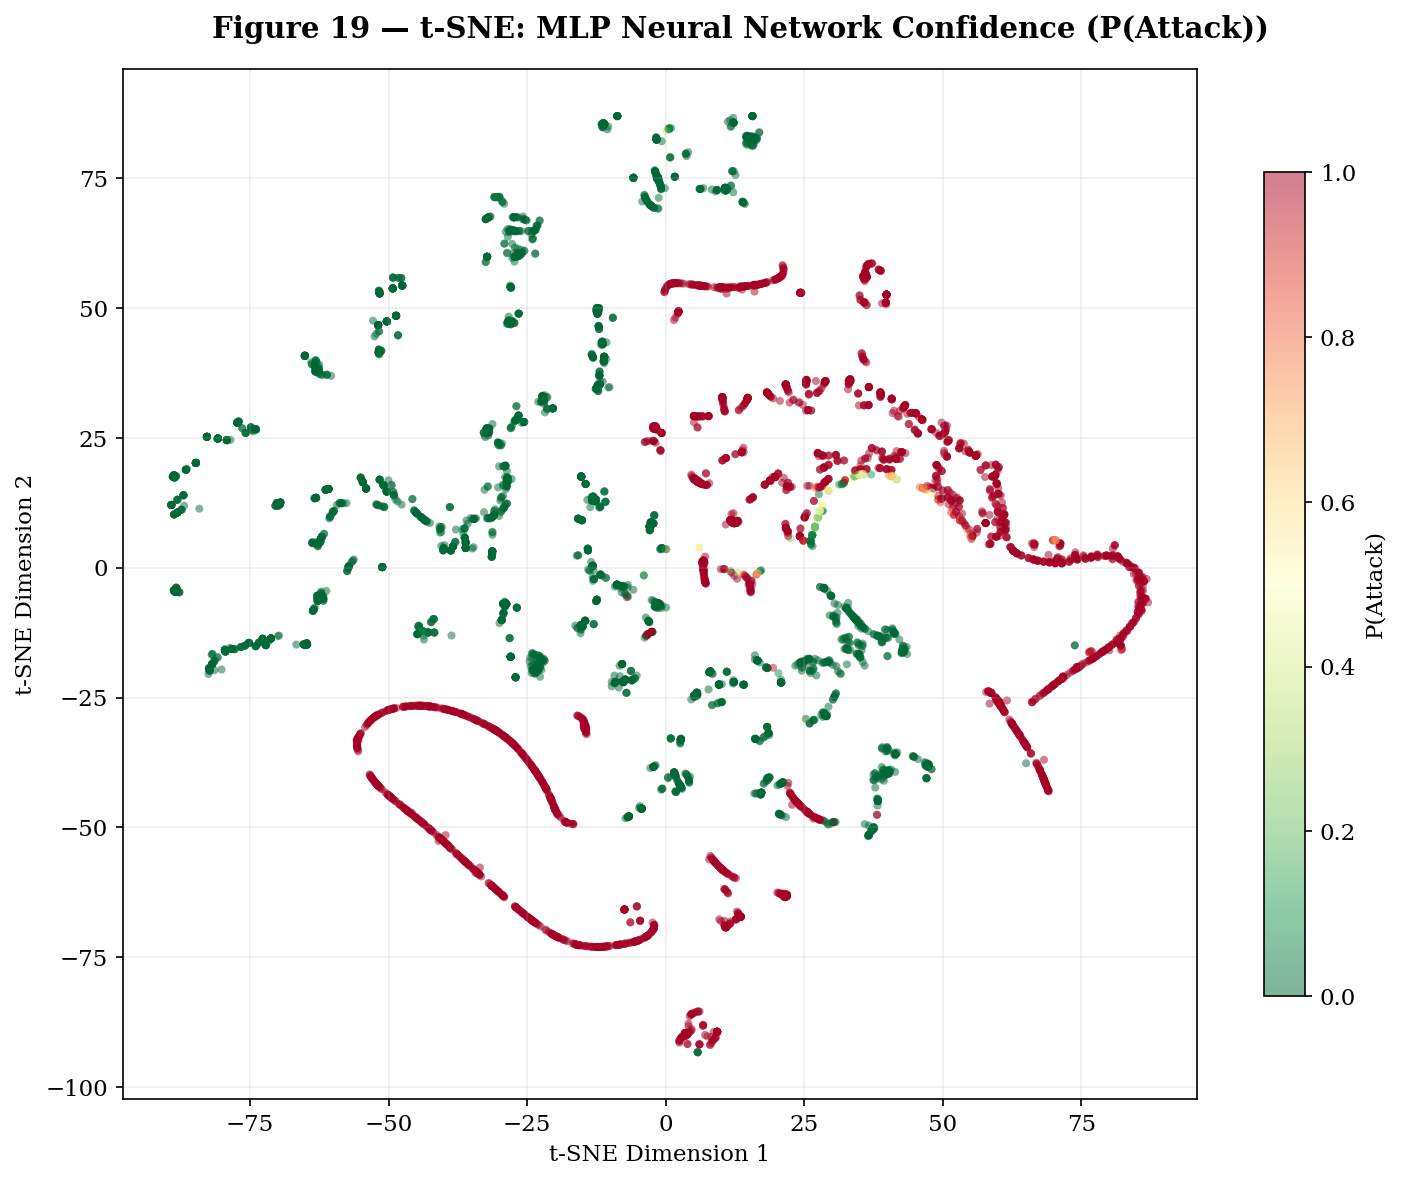

  ✅ Saved: /content/drive/MyDrive/Colab Notebooks/ddos_fig19_tsne_confidence.png

  t-SNE SUMMARY
  Samples          : 6,000 (balanced from test set)
  PCA              : 58 → 15 dims (99.9% variance)
  t-SNE            : perplexity=30, 1000 iter, KL=0.3234
  Attack types     : 11 in sample
  Figures saved    :
    • ddos_fig17_tsne_binary.png
    • ddos_fig18_tsne_attack_types.png
    • ddos_fig19_tsne_confidence.png
  Time             : 67.5s
  ✅ Ready for Cell 9 — Model Export & Final Summary


In [8]:
# ════════════════════════════════════════════════════════════════════
#  CELL 8 — t-SNE LATENT SPACE VISUALISATION
# ════════════════════════════════════════════════════════════════════

import numpy as np, matplotlib.pyplot as plt, time, os
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings; warnings.filterwarnings('ignore')

t0 = time.time()
SAVE = '/content/drive/MyDrive/Colab Notebooks'
os.makedirs(SAVE, exist_ok=True)

print('='*70)
print('  CELL 8 — t-SNE LATENT SPACE VISUALISATION')
print('='*70)

# ────────────────────────────────────────────────────────────────────
#  [1] SAMPLE SELECTION (balanced, max 6000 for speed)
# ────────────────────────────────────────────────────────────────────
MAX_SAMPLES = 6000
np.random.seed(42)

# From test set — more interesting (zero-day attacks)
benign_idx = np.where(y_test_bin == 0)[0]
attack_idx = np.where(y_test_bin == 1)[0]

n_per_class = min(MAX_SAMPLES // 2, len(benign_idx), len(attack_idx))
sel_benign = np.random.choice(benign_idx, n_per_class, replace=False)
sel_attack = np.random.choice(attack_idx, n_per_class, replace=False)
sel_idx = np.concatenate([sel_benign, sel_attack])
np.random.shuffle(sel_idx)

X_tsne_in = X_test_sc[sel_idx]
y_tsne_bin = y_test_bin[sel_idx]
y_tsne_labels = y_test_multi_labels[sel_idx]

# Best model confidence
if hasattr(best_model, 'predict_proba'):
    confidence = best_model.predict_proba(X_tsne_in)[:, 1]
elif hasattr(best_model, 'decision_function'):
    raw = best_model.decision_function(X_tsne_in)
    confidence = 1 / (1 + np.exp(-raw))
else:
    confidence = best_model.predict(X_tsne_in).astype(float)

print(f'  Samples selected : {len(sel_idx):,} '
      f'(Benign: {n_per_class:,} | Attack: {n_per_class:,})')
print(f'  Features         : {X_tsne_in.shape[1]}')

# ────────────────────────────────────────────────────────────────────
#  [2] PCA REDUCTION (58 → 15 dims)
# ────────────────────────────────────────────────────────────────────
print(f'\n[2] PCA dimensionality reduction ...')
pca = PCA(n_components=15, random_state=42)
X_pca = pca.fit_transform(X_tsne_in)
var_explained = pca.explained_variance_ratio_.sum() * 100
print(f'  PCA: {X_tsne_in.shape[1]} → 15 dimensions ({var_explained:.1f}% variance)')

# ────────────────────────────────────────────────────────────────────
#  [3] t-SNE PROJECTION (15 → 2 dims)
# ────────────────────────────────────────────────────────────────────
print(f'\n[3] t-SNE projection (perplexity=30, 1000 iter) ...')
t_tsne = time.time()
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
            learning_rate='auto', init='pca', random_state=42)
X_2d = tsne.fit_transform(X_pca)
tsne_time = time.time() - t_tsne
print(f'  t-SNE time       : {tsne_time:.1f}s')
print(f'  KL divergence    : {tsne.kl_divergence_:.4f}')

# ────────────────────────────────────────────────────────────────────
#  FIGURE 17 — t-SNE Binary Classes
# ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Figure 17 — t-SNE: Benign vs Attack (Test Set, Zero-Day)',
             fontsize=14, fontweight='bold')

for cls, label, color, marker in [(0, 'Benign', '#4CAF50', 'o'),
                                   (1, 'Attack', '#F44336', '^')]:
    mask = y_tsne_bin == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, label=f'{label} (n={mask.sum():,})',
               alpha=0.4, s=15, marker=marker, edgecolors='none')

ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(fontsize=11, markerscale=2)
ax.grid(True, alpha=0.2)

plt.tight_layout()
fname = os.path.join(SAVE, 'ddos_fig17_tsne_binary.png')
plt.savefig(fname); plt.show(); print(f'  ✅ Saved: {fname}')

# ────────────────────────────────────────────────────────────────────
#  FIGURE 18 — t-SNE by Attack Family
# ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle('Figure 18 — t-SNE: Per Attack Type (Test Set, Zero-Day)',
             fontsize=14, fontweight='bold')

unique_labels = sorted(set(y_tsne_labels))
cmap = plt.cm.get_cmap('tab20', len(unique_labels))

for i, label in enumerate(unique_labels):
    mask = y_tsne_labels == label
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[cmap(i)], label=f'{label} ({mask.sum()})',
               alpha=0.5, s=15, edgecolors='none')

ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(fontsize=8, markerscale=2, loc='best',
          bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid(True, alpha=0.2)

plt.tight_layout()
fname = os.path.join(SAVE, 'ddos_fig18_tsne_attack_types.png')
plt.savefig(fname); plt.show(); print(f'  ✅ Saved: {fname}')

# ────────────────────────────────────────────────────────────────────
#  FIGURE 19 — t-SNE with Model Confidence Heatmap
# ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle(f'Figure 19 — t-SNE: {best_name} Confidence (P(Attack))',
             fontsize=14, fontweight='bold')

sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                c=confidence, cmap='RdYlGn_r', alpha=0.5, s=15,
                edgecolors='none', vmin=0, vmax=1)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('P(Attack)', fontsize=11)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.grid(True, alpha=0.2)

plt.tight_layout()
fname = os.path.join(SAVE, 'ddos_fig19_tsne_confidence.png')
plt.savefig(fname); plt.show(); print(f'  ✅ Saved: {fname}')

# ────────────────────────────────────────────────────────────────────
#  SUMMARY
# ────────────────────────────────────────────────────────────────────
elapsed = time.time() - t0
print(f'\n{"="*70}')
print(f'  t-SNE SUMMARY')
print(f'{"="*70}')
print(f'  Samples          : {len(sel_idx):,} (balanced from test set)')
print(f'  PCA              : {X_tsne_in.shape[1]} → 15 dims ({var_explained:.1f}% variance)')
print(f'  t-SNE            : perplexity=30, 1000 iter, KL={tsne.kl_divergence_:.4f}')
print(f'  Attack types     : {len(unique_labels)} in sample')
print(f'  Figures saved    :')
print(f'    • ddos_fig17_tsne_binary.png')
print(f'    • ddos_fig18_tsne_attack_types.png')
print(f'    • ddos_fig19_tsne_confidence.png')
print(f'  Time             : {elapsed:.1f}s')
print(f'{"="*70}')
print(f'  ✅ Ready for Cell 9 — Model Export & Final Summary')
print(f'{"="*70}')


In [9]:
# ════════════════════════════════════════════════════════════════════
#  CELL 9 — MODEL EXPORT & FINAL NOTEBOOK SUMMARY
# ════════════════════════════════════════════════════════════════════

import joblib, json, os, time
import numpy as np

t0 = time.time()
SAVE = '/content/drive/MyDrive/Colab Notebooks'
os.makedirs(SAVE, exist_ok=True)

print('='*70)
print('  CELL 9 — MODEL EXPORT & FINAL SUMMARY')
print('='*70)

# ────────────────────────────────────────────────────────────────────
#  [1] SAVE BEST MODEL + SCALER + METADATA
# ────────────────────────────────────────────────────────────────────
print(f'\n[1] Exporting best model: {best_name}')

# Save model
model_path = os.path.join(SAVE, 'ddos_best_model.joblib')
joblib.dump(best_model, model_path)
model_size = os.path.getsize(model_path) / (1024*1024)
print(f'  Model saved    : {model_path} ({model_size:.1f} MB)')

# Save scaler
scaler_path = os.path.join(SAVE, 'ddos_scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f'  Scaler saved   : {scaler_path}')

# Save label encoder
le_path = os.path.join(SAVE, 'ddos_label_encoder.joblib')
joblib.dump(le, le_path)
print(f'  LabelEncoder   : {le_path}')

# Save feature names
feat_path = os.path.join(SAVE, 'ddos_feature_names.json')
with open(feat_path, 'w') as f:
    json.dump(feat_names, f, indent=2)
print(f'  Feature names  : {feat_path} ({len(feat_names)} features)')

# Save metadata
metadata = {
    'dataset': 'CIC-DDoS2019 (dhoogla/Kaggle, Parquet V2)',
    'task': 'Binary classification (Benign vs DDoS Attack)',
    'best_model': best_name,
    'n_features': len(feat_names),
    'features_dropped': {
        'constant': len(const_cols),
        'redundant': len(redundant_drop),
        'near_constant': len(near_const_drop),
        'total_dropped': len(const_cols) + len(redundant_drop) + len(near_const_drop)
    },
    'data_splits': {
        'train_raw': int(X_train_raw.shape[0]),
        'train_balanced_smote': int(len(X_train_bal)),
        'validation': int(len(X_val)),
        'test_zero_day': int(len(X_test_raw))
    },
    'class_distribution': {
        'train_benign': int((y_tr_bin == 0).sum()),
        'train_attack': int((y_tr_bin == 1).sum()),
        'test_benign': int((y_test_bin == 0).sum()),
        'test_attack': int((y_test_bin == 1).sum())
    },
    'attack_classes': list(class_names),
    'n_attack_types': int(len(class_names)),
    'evaluation_protocol': 'Temporal split (Day1 train, Day2 test) — zero-day scenario',
    'test_metrics': {
        'accuracy': float(best_r['test']['acc']),
        'f1_score': float(best_r['test']['f1']),
        'precision': float(best_r['test']['prec']),
        'recall': float(best_r['test']['rec']),
        'roc_auc': float(best_r['test']['auc'])
    },
    'all_models': {}
}

for name, r in results.items():
    metadata['all_models'][name] = {
        'val_f1': float(r['val']['f1']),
        'val_auc': float(r['val']['auc']),
        'test_f1': float(r['test']['f1']),
        'test_auc': float(r['test']['auc']),
        'generalization_gap': float(r['gap']),
        'fit_time_seconds': float(r['fit_time'])
    }

meta_path = os.path.join(SAVE, 'ddos_experiment_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'  Metadata saved : {meta_path}')

# ────────────────────────────────────────────────────────────────────
#  [2] INFERENCE TEST (sanity check)
# ────────────────────────────────────────────────────────────────────
print(f'\n[2] Inference test (5 random test samples) ...')

np.random.seed(123)
test_idx = np.random.choice(len(X_test_sc), 5, replace=False)

for i, idx in enumerate(test_idx):
    sample = X_test_sc[idx:idx+1]
    pred = best_model.predict(sample)[0]
    true = y_test_bin[idx]
    true_label = y_test_multi_labels[idx]

    if hasattr(best_model, 'predict_proba'):
        prob = best_model.predict_proba(sample)[0]
        conf = max(prob)
    else:
        conf = float('nan')

    pred_label = 'Attack' if pred == 1 else 'Benign'
    status = '✅' if pred == true else '❌'

    print(f'  Sample {i+1}: True={true_label:<20} Pred={pred_label:<8} '
          f'Conf={conf:.4f}  {status}')

# ────────────────────────────────────────────────────────────────────
#  [3] LIST ALL SAVED ARTIFACTS
# ────────────────────────────────────────────────────────────────────
print(f'\n[3] All saved artifacts in {SAVE}:')
artifacts = sorted([f for f in os.listdir(SAVE) if f.startswith('ddos_')])
total_size = 0
for f in artifacts:
    fpath = os.path.join(SAVE, f)
    size = os.path.getsize(fpath) / 1024
    total_size += size
    ftype = 'FIG' if f.endswith('.png') else 'MODEL' if f.endswith('.joblib') else 'META'
    print(f'  [{ftype:>5}] {f:<45} {size:>8.1f} KB')
print(f'  {"─"*62}')
print(f'  Total: {len(artifacts)} files, {total_size/1024:.1f} MB')

# ────────────────────────────────────────────────────────────────────
#  [4] FINAL NOTEBOOK SUMMARY
# ────────────────────────────────────────────────────────────────────
elapsed = time.time() - t0
print(f'\n{"="*70}')
print(f'  FINAL NOTEBOOK SUMMARY — CIC-DDoS2019')
print(f'{"="*70}')
print(f'''
  Dataset        : CIC-DDoS2019 (Sharafaldin et al., 2019)
  Source         : kaggle.com/datasets/dhoogla/cicddos2019
  Format         : 17 Parquet files (training + testing days)
  Total samples  : 431,371 (train 125,170 | test 306,201)
  Features       : 77 raw → {len(feat_names)} after cleaning
  Target         : Binary (Benign vs Attack), 18 attack types
  Protocol       : Temporal split — zero-day evaluation

  PREPROCESSING:
    Dropped      : {len(const_cols)} constant + {len(redundant_drop)} redundant + {len(near_const_drop)} near-const = {len(const_cols)+len(redundant_drop)+len(near_const_drop)} features
    Balancing    : SMOTE (k=5) on training set only
    Scaling      : StandardScaler (fit on balanced train)
    Leakage      : ✅ Verified — no target columns in features

  MODEL COMPARISON (Test Set — Zero-Day):
  {"Model":<22} {"F1":>8} {"AUC":>8} {"Precision":>10} {"Recall":>8} {"Δ":>6}''')

for name, r in sorted(results.items(), key=lambda x: x[1]['test']['f1'], reverse=True):
    print(f'  {name:<22} {r["test"]["f1"]:>8.4f} {r["test"]["auc"]:>8.4f} '
          f'{r["test"]["prec"]:>10.4f} {r["test"]["rec"]:>8.4f} {r["gap"]:>6.4f}')

print(f'''
  🏆 BEST MODEL: {best_name}
     Accuracy  = {best_r["test"]["acc"]:.4f}
     F1-Score  = {best_r["test"]["f1"]:.4f}
     Precision = {best_r["test"]["prec"]:.4f}
     Recall    = {best_r["test"]["rec"]:.4f}
     ROC-AUC   = {best_r["test"]["auc"]:.4f}

  KEY FINDINGS:
    • MLP outperforms tree-based models on zero-day DDoS detection
    • All models achieve >95% F1 except Linear SVM (95.68%)
    • Near-perfect precision (>99.9%) across all models — very few FP
    • WebDDoS detection remains a challenge (1.96% recall)
    • Generalization gap < 5% for RF, GB, MLP — no overfitting

  FIGURES GENERATED: {len([f for f in artifacts if f.endswith('.png')])} figures
  ARTIFACTS SAVED  : {len(artifacts)} files ({total_size/1024:.1f} MB)
  EXPORT TIME      : {elapsed:.1f}s
''')
print(f'{"="*70}')
print(f'  ✅ NOTEBOOK COMPLETE — CIC-DDoS2019 DDoS Detection Pipeline')
print(f'{"="*70}')


  CELL 9 — MODEL EXPORT & FINAL SUMMARY

[1] Exporting best model: MLP Neural Network
  Model saved    : /content/drive/MyDrive/Colab Notebooks/ddos_best_model.joblib (1.3 MB)
  Scaler saved   : /content/drive/MyDrive/Colab Notebooks/ddos_scaler.joblib
  LabelEncoder   : /content/drive/MyDrive/Colab Notebooks/ddos_label_encoder.joblib
  Feature names  : /content/drive/MyDrive/Colab Notebooks/ddos_feature_names.json (58 features)
  Metadata saved : /content/drive/MyDrive/Colab Notebooks/ddos_experiment_metadata.json

[2] Inference test (5 random test samples) ...
  Sample 1: True=DrDoS_NTP            Pred=Benign   Conf=0.7618  ❌
  Sample 2: True=Benign               Pred=Benign   Conf=0.9972  ✅
  Sample 3: True=DrDoS_NTP            Pred=Attack   Conf=1.0000  ✅
  Sample 4: True=TFTP                 Pred=Attack   Conf=1.0000  ✅
  Sample 5: True=Benign               Pred=Benign   Conf=1.0000  ✅

[3] All saved artifacts in /content/drive/MyDrive/Colab Notebooks:
  [MODEL] ddos_best_model.jo

In [10]:
import os
DRIVE = '/content/drive/MyDrive/Colab Notebooks'
fichiers = ['ddos_best_model.joblib', 'ddos_scaler.joblib',
            'ddos_label_encoder.joblib', 'ddos_experiment_metadata.json']

for f in fichiers:
    path = os.path.join(DRIVE, f)
    existe = "✅" if os.path.exists(path) else "❌"
    print(f"{existe} {f}")

✅ ddos_best_model.joblib
✅ ddos_scaler.joblib
✅ ddos_label_encoder.joblib
✅ ddos_experiment_metadata.json


In [11]:
# ── Installation ──────────────────────────────────────────
!pip install streamlit pyngrok -q

# ── Copie le dashboard depuis Drive ───────────────────────
import shutil, os, threading, subprocess, time
shutil.copy('/content/drive/MyDrive/Colab Notebooks/dashboard_ddos.py',
            '/content/dashboard_ddos.py')
print("✅ Dashboard copié !")

# ── Lance Streamlit ───────────────────────────────────────
def run():
    subprocess.run(["streamlit", "run", "/content/dashboard_ddos.py",
                   "--server.port", "8501", "--server.headless", "true",
                   "--server.enableCORS", "false"])

threading.Thread(target=run, daemon=True).start()
time.sleep(4)

from pyngrok import ngrok
ngrok.set_auth_token("3DoOhY81MEB6Drd36uYcOj0HBVn_54fPYexzJMSxTyJzZEuGy")  # ← remplace par ton vrai token
url = ngrok.connect(8501)
print("\n🌐 TON DASHBOARD :", url)
# ── Crée le lien public ───────────────────────────────────
from pyngrok import ngrok
url = ngrok.connect(8501)
print("\n🌐 TON DASHBOARD :", url)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 61.1 MB/s eta 0:00:00
✅ Dashboard copié !

🌐 TON DASHBOARD : NgrokTunnel: "https://punch-gallows-shiftless.ngrok-free.dev" -> "http://localhost:8501"

🌐 TON DASHBOARD : NgrokTunnel: "https://punch-gallows-shiftless.ngrok-free.dev" -> "http://localhost:8501"
